<a href="https://colab.research.google.com/github/ILKA777/Loan-Approval-Prediction/blob/main/%D0%9F%D1%80%D0%BE%D0%B5%D0%BA%D1%82%D0%BD%D1%8B%D0%B9_%D0%BF%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D0%BA%D1%83%D0%BC_9v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Проектный практикум 9

## Загрузка данных и подготовка

### Загрузка данных

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving test.csv to test.csv
Saving train.csv to train.csv


In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

Установка необходимых библиотек

In [ ]:
!pip install phik imbalanced-learn ydata_profiling catboost xgboost -q

import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from matplotlib.patches import Patch
import numpy as np
import phik
from phik.report import plot_correlation_matrix
from collections import Counter
from sklearn.linear_model import LinearRegression, ElasticNet, LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn import tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, LabelEncoder
from sklearn.metrics import (auc, r2_score, roc_auc_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix,
                             roc_curve, precision_recall_curve)
from sklearn.model_selection import (cross_validate, KFold, train_test_split,
                                     cross_val_score, StratifiedKFold)
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import SelectFromModel
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.utils import class_weight
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTEENN, SMOTETomek
from ydata_profiling import ProfileReport
from catboost import CatBoostClassifier
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

# Чтение файлов
train_data = pd.read_csv('train.csv')

# Вывод первых 5 строк
print(train_data.head())


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 21.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 398.7/398.7 kB 35.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 26.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 111.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 3.2 MB/s eta 0:00:00
   id  person_age  person_income person_home_ownership  person_emp_length  \
0   0          37          35000                  RENT                0.0   
1   1          22          56000                   OWN                6.0   
2   2          29          28800                   OWN                8.0   
3   3          30          70000                  RENT               14.0   
4   4          22          60000                  RENT    

### Создание классов:

#### Для предобработки данных

In [ ]:
class DataPreprocessor(BaseEstimator, TransformerMixin):

    def __init__(self):
        self.grade_map = {'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5, 'F': 6, 'G': 7}
        self.columns_order = None
        self.label_encoders = {}
        self.categorical_cols = []

    def fit(self, X, y=None):
        X = X.copy()

        self.columns_order = X.columns.tolist()

        self.categorical_cols = X.select_dtypes(
            include=['object', 'category']
        ).columns.tolist()

        for col in self.categorical_cols:
            le = LabelEncoder()
            unique_values = X[col].astype(str).unique()
            le.fit(list(unique_values))
            self.label_encoders[col] = le

        return self

    def transform(self, X, y=None):
        X = X.copy()

        if 'loan_grade' in X.columns:
            X['loan_grade'] = X['loan_grade'].map(self.grade_map)
            X['loan_grade'] = X['loan_grade'].fillna(X['loan_grade'].median())

        if 'cb_person_default_on_file' in X.columns:
            X['cb_person_default_on_file'] = (
                X['cb_person_default_on_file']
                .map({'Y': 1, 'N': 0})
                .fillna(0)
                .astype(int)
            )

        for col in self.categorical_cols:
            if col in ['loan_grade', 'cb_person_default_on_file']:
                continue

            if col in X.columns and col in self.label_encoders:
                le = self.label_encoders[col]
                try:
                    X[col] = X[col].astype(str)
                    mask = ~X[col].isin(le.classes_)
                    if mask.any():
                        X.loc[mask, col] = le.classes_[0]
                    X[col] = le.transform(X[col])
                except Exception as e:
                    print(f"Ошибка при кодировании {col}: {e}")
                    X[col] = pd.factorize(X[col])[0]

        numeric_cols = X.select_dtypes(include=[np.number]).columns
        for col in numeric_cols:
            if X[col].isnull().any():
                X[col] = X[col].fillna(X[col].median())

        if self.columns_order is not None:
            for col in self.columns_order:
                if col not in X.columns:
                    X[col] = 0
            X = X[self.columns_order]

        for col in X.columns:
            X[col] = pd.to_numeric(X[col], errors='coerce').fillna(0)

        return X

#### Для Feature Engineering(FE)

In [ ]:
class FeatureEngineer(BaseEstimator, TransformerMixin):

    def __init__(self, add_features=True):
        self.add_features = add_features
        self.features_to_create = []

    def fit(self, X, y=None):
        return self

    def transform(self, X, y=None):
        if not self.add_features:
            return X

        X = X.copy()

        # 1. Соотношение кредита к доходу
        if all(col in X.columns for col in ['loan_amnt', 'person_income']):
            X['loan_to_income'] = X['loan_amnt'] / (X['person_income'] + 1)
            X['loan_to_income'] = X['loan_to_income'].fillna(0).astype(float)

        # 2. Кредитная история относительно возраста
        if all(col in X.columns for col in ['cb_person_cred_hist_length', 'person_age']):
            X['credit_history_to_age'] = X['cb_person_cred_hist_length'] / (X['person_age'] + 1)
            X['credit_history_to_age'] = X['credit_history_to_age'].fillna(0).astype(float)

        # 3. Стаж работы относительно возраста
        if all(col in X.columns for col in ['person_emp_length', 'person_age']):
            X['emp_length_to_age'] = X['person_emp_length'] / (X['person_age'] + 1)
            X['emp_length_to_age'] = X['emp_length_to_age'].fillna(0).astype(float)

        # 4. Логарифм дохода
        if 'person_income' in X.columns:
            X['log_income'] = np.log1p(X['person_income'].clip(lower=0))
            X['log_income'] = X['log_income'].fillna(0).astype(float)

        # 5. Логарифм размера кредита
        if 'loan_amnt' in X.columns:
            X['log_loan_amnt'] = np.log1p(X['loan_amnt'].clip(lower=0))
            X['log_loan_amnt'] = X['log_loan_amnt'].fillna(0).astype(float)

        # 6. Взаимодействие: возраст × процентная ставка
        if all(col in X.columns for col in ['person_age', 'loan_int_rate']):
            X['age_interest_interaction'] = X['person_age'] * X['loan_int_rate']
            X['age_interest_interaction'] = X['age_interest_interaction'].fillna(0).astype(float)

        return X

#### Для сэмплирования

In [ ]:
class SamplingTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, sampler=None):
        self.sampler = sampler

    def fit(self, X, y=None):
        return self

    def transform(self, X, y=None):
        return X

## Первичный анализ

In [ ]:
profile = ProfileReport(train_data, title="Profiling Report")

profile

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 13/13 [00:01<00:00, 11.45it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

В наборе данных 13 столбцов, пропусков и дубликатов нет. 8 числовых признаков (включая id), 4 категориальных
Целевая переменная:

loan_status (0/1) - бинарная классификация (одобрен/не одобрен кредит)

Признаки:

Демографические: person_age, person_home_ownership

Финансовые: person_income, loan_amnt, loan_int_rate, loan_percent_income

Кредитная история: cb_person_default_on_file, cb_person_cred_hist_length

Профессиональные: person_emp_length

Цель кредита: loan_intent

Кредитный рейтинг: loan_grade

## Предобработка данных

In [ ]:
print(train_data.columns)

Index(['id', 'person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_percent_income', 'cb_person_default_on_file',
       'cb_person_cred_hist_length', 'loan_status'],
      dtype='object')


Общая картина

Число записей: 58 645

Признаки: 12, без пропусков

Типы данных:

int64: возраст, доход, сумма кредита, длина кредитной истории, статус кредита

float64: стаж работы, процент дохода на кредит, процентная ставка

object: категориальные признаки (home_ownership, loan_intent, loan_grade, default_on_file)

### Удаляем столбец ID

так как он не несет в себе полезной информации для модели

In [ ]:
train_data.drop('id', axis=1, inplace=True)
print(train_data.head())

   person_age  person_income person_home_ownership  person_emp_length  \
0          37          35000                  RENT                0.0   
1          22          56000                   OWN                6.0   
2          29          28800                   OWN                8.0   
3          30          70000                  RENT               14.0   
4          22          60000                  RENT                2.0   

  loan_intent loan_grade  loan_amnt  loan_int_rate  loan_percent_income  \
0   EDUCATION          B       6000          11.49                 0.17   
1     MEDICAL          C       4000          13.35                 0.07   
2    PERSONAL          A       6000           8.90                 0.21   
3     VENTURE          B      12000          11.11                 0.17   
4     MEDICAL          A       6000           6.92                 0.10   

  cb_person_default_on_file  cb_person_cred_hist_length  loan_status  
0                         N            

**ЗАМЕЧАНИЯ К ДАННЫМ** Обнаружен возраст - 123 года (аномальный для взятия кредита) Обнаружен доход в месяц 1900000руб, подозрительно высокий доход (возможно выбросы). Обнаружен стаж работы - 123 года - аномалия

Мы выявили аномалии в:

person_age → значения > 100 явно выбросы (ВОЗРАСТ)

person_emp_length → значения > 50 явно выбросы (более реальный предел ~40 лет) (СТАЖ РАБОТЫ)

person_income → экстремально высокие значения, ограничивать не будем, вдруг заемщик реально много зарабатывает (ДОХОД ЗАЕМЩИКА)

### Фильтрация выбросов (возраст, стаж)

Ограничиваем возраст заемщика до 100 лет
Стаж до 50 лет

In [ ]:
# Ограничение возраста и стажа
train_data = train_data[train_data['person_age'] <= 100]
train_data = train_data[train_data['person_emp_length'] <= 50]

# Проверяем размеры после фильтрации
train_data[['person_age','person_emp_length']].describe()

,person_age,person_emp_length
count,58642.000000,58642.000000
mean,27.549333,4.696941
std,6.020420,3.899139
min,20.000000,0.000000
25%,23.000000,2.000000
50%,26.000000,4.000000
75%,30.000000,7.000000
max,84.000000,41.000000


### Анализ коллинеарности

interval columns not set, guessing: ['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'loan_status']


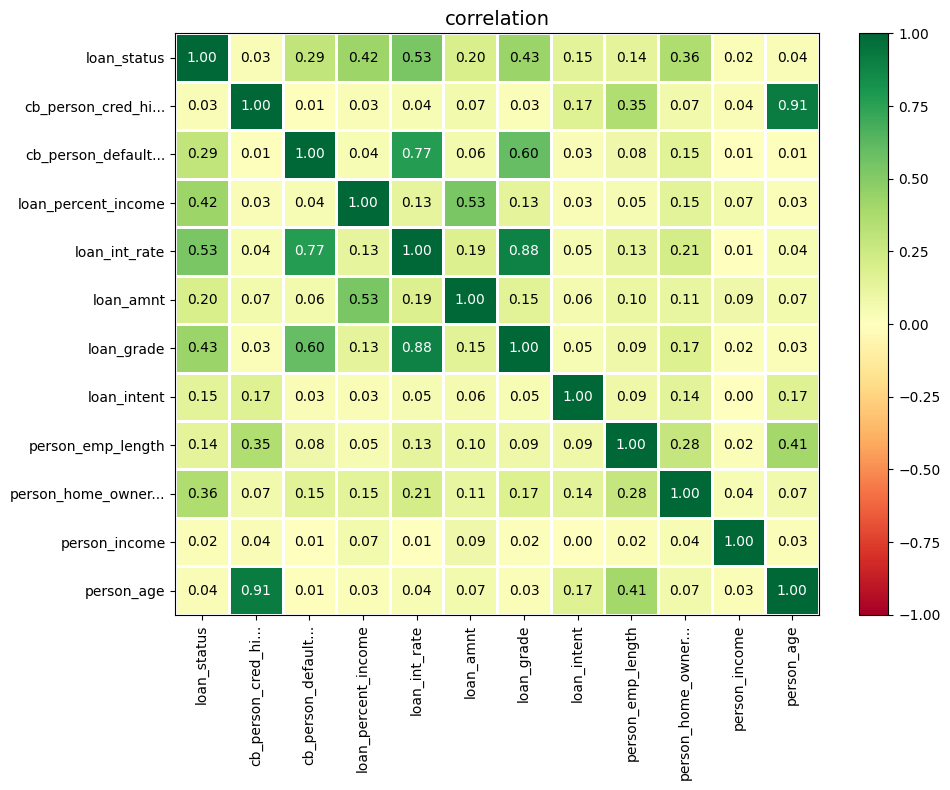

In [ ]:
corr_matrix = train_data.phik_matrix()
plot_correlation_matrix(corr_matrix.values, x_labels=corr_matrix.columns, y_labels=corr_matrix.index, figsize=(10, 8))

Высокая коллинеарность между возрастом заемщика и длиной кредитной истории – 0,91, однако бывают случаи, когда человек начинает брать кредиты в зрелом возрасте, и этой зависимости не будет. Поэтому оставляем.
Высокая коллинеарность между неуплатой кредита заемщиком в прошлом и кредитным рейтингом заемщика – 0,88, т.к. менее 0,9 оставляем
Высокая коллинеарность между ежемесячным платежом по кредиту и долей ежемесячного платежа от дохода заемщика. Тут все зависит от дохода. Если доход высокий, то такой зависимости не будет.
В остальной коллинеарность не такая уж и высокая.
Нули в стаже работы – это не ошибка, а отсутствие стажа у молодого поколения.


In [ ]:
from sklearn.model_selection import train_test_split

# Отделяем признаки от целевой переменной
X_raw = train_data.drop('loan_status', axis=1)
y = train_data['loan_status']

# Разделяем на тренировочную и тестовую выборки 75/25
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y,
    test_size=0.25, # 25% данных для теста
    random_state=42,  # для воспроизводимости
    stratify=y  # сохраняем соотношение классов
)

# Проверим размеры
print(f"\nРазмеры после предобработки и фильтрации:")
print(f"X_train_raw: {X_train_raw.shape}")
print(f"X_test_raw: {X_test_raw.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test: {y_test.shape}")


Размеры после предобработки и фильтрации:
X_train_raw: (43981, 11)
X_test_raw: (14661, 11)
y_train: (43981,)
y_test: (14661,)


## Анализ дисбаланса классов

In [ ]:
# Применяем препроцессинг для анализа дисбаланса
print("\n" + "="*60)
print("ПОДГОТОВКА ДАННЫХ ДЛЯ АНАЛИЗА ДИСБАЛАНСА")
print("="*60)

temp_preprocessor = DataPreprocessor()
X_train_processed = temp_preprocessor.fit_transform(X_train_raw)

print(f"Размер X_train_raw: {X_train_raw.shape}")
print(f"Размер X_train_processed: {X_train_processed.shape}")


ПОДГОТОВКА ДАННЫХ ДЛЯ АНАЛИЗА ДИСБАЛАНСА
Размер X_train_raw: (43981, 11)
Размер X_train_processed: (43981, 11)



АНАЛИЗ ДИСБАЛАНСА КЛАССОВ (loan_status)
Распределение классов:
loan_status
0    37719
1     6262
Name: count, dtype: int64

Процентное соотношение:
loan_status
0    85.76
1    14.24
Name: proportion, dtype: float64


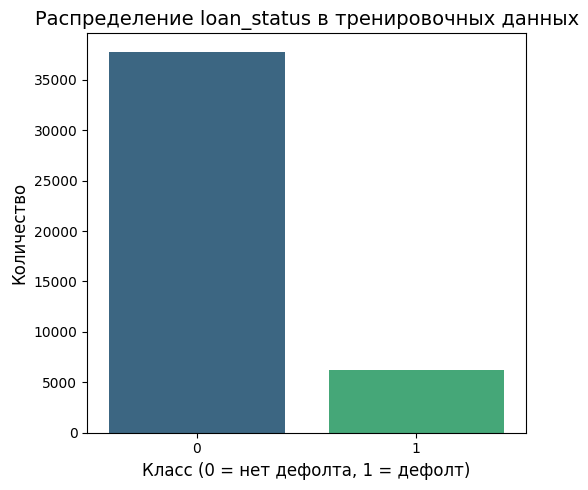


Соотношение классов: 6.0:1
Дисбаланс: умеренный


In [ ]:
print("\n" + "="*60)
print("АНАЛИЗ ДИСБАЛАНСА КЛАССОВ (loan_status)")
print("="*60)

# Распределение целевой переменной
print("Распределение классов:")
class_distribution = y_train.value_counts()
print(class_distribution)

print("\nПроцентное соотношение:")
class_percentage = y_train.value_counts(normalize=True) * 100
print(class_percentage.round(2))

# Визуализация
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
sns.countplot(x=y_train, palette='viridis')
plt.title('Распределение loan_status в тренировочных данных', fontsize=14)
plt.xlabel('Класс (0 = нет дефолта, 1 = дефолт)', fontsize=12)
plt.ylabel('Количество', fontsize=12)



plt.tight_layout()
plt.show()

# Анализ дисбаланса
imbalance_ratio = class_distribution[0] / class_distribution[1]

print(f"\nСоотношение классов: {imbalance_ratio:.1f}:1")
print(f"Дисбаланс: {'СИЛЬНЫЙ' if imbalance_ratio > 10 else 'умеренный' if imbalance_ratio > 5 else 'слабый'}")

### Борьба с дисбалансом классов

In [ ]:
print("\n" + "="*60)
print("МЕТОДЫ БОРЬБЫ С ДИСБАЛАНСОМ КЛАССОВ")
print("="*60)

# Вычисляем веса классов для использования в моделях
classes = np.unique(y_train)
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)
class_weight_dict = dict(zip(classes, class_weights))
print(f"Веса классов (balanced): {class_weight_dict}")

# Подготовка методов сэмплинга
sampling_methods = {
    'Без сэмплинга': None,
    'SMOTE': SMOTE(random_state=42),
    'RandomOverSampler': RandomOverSampler(random_state=42),
    'RandomUnderSampler': RandomUnderSampler(random_state=42),
    'SMOTEENN': SMOTEENN(random_state=42),
    'SMOTETomek': SMOTETomek(random_state=42)
}

print("\nДоступные методы сэмплинга:")
for method_name in sampling_methods.keys():
    print(f"  - {method_name}")


МЕТОДЫ БОРЬБЫ С ДИСБАЛАНСОМ КЛАССОВ
Веса классов (balanced): {np.int64(0): np.float64(0.5830085633235239), np.int64(1): np.float64(3.5117374640689873)}

Доступные методы сэмплинга:
  - Без сэмплинга
  - SMOTE
  - RandomOverSampler
  - RandomUnderSampler
  - SMOTEENN
  - SMOTETomek


### Сравнение методов сэмплинга


СРАВНЕНИЕ МЕТОДОВ БОРЬБЫ С ДИСБАЛАНСОМ

Без сэмплинга:
  Размер выборки: 43981 записей
  Распределение классов: [37719  6262]
  ROC-AUC: 0.7832 (+/- 0.0032)

SMOTE:
  Размер выборки: 75438 записей
  Распределение классов: [37719 37719]
  ROC-AUC: 0.7562 (+/- 0.0019)

RandomOverSampler:
  Размер выборки: 75438 записей
  Распределение классов: [37719 37719]
  ROC-AUC: 0.7560 (+/- 0.0029)

RandomUnderSampler:
  Размер выборки: 12524 записей
  Распределение классов: [6262 6262]
  ROC-AUC: 0.7558 (+/- 0.0089)

SMOTEENN:
  Размер выборки: 59882 записей
  Распределение классов: [29075 30807]
  ROC-AUC: 0.8199 (+/- 0.0049)

SMOTETomek:
  Размер выборки: 73052 записей
  Распределение классов: [36526 36526]
  ROC-AUC: 0.7644 (+/- 0.0026)

ЛУЧШИЙ МЕТОД: SMOTEENN
ROC-AUC: 0.8199


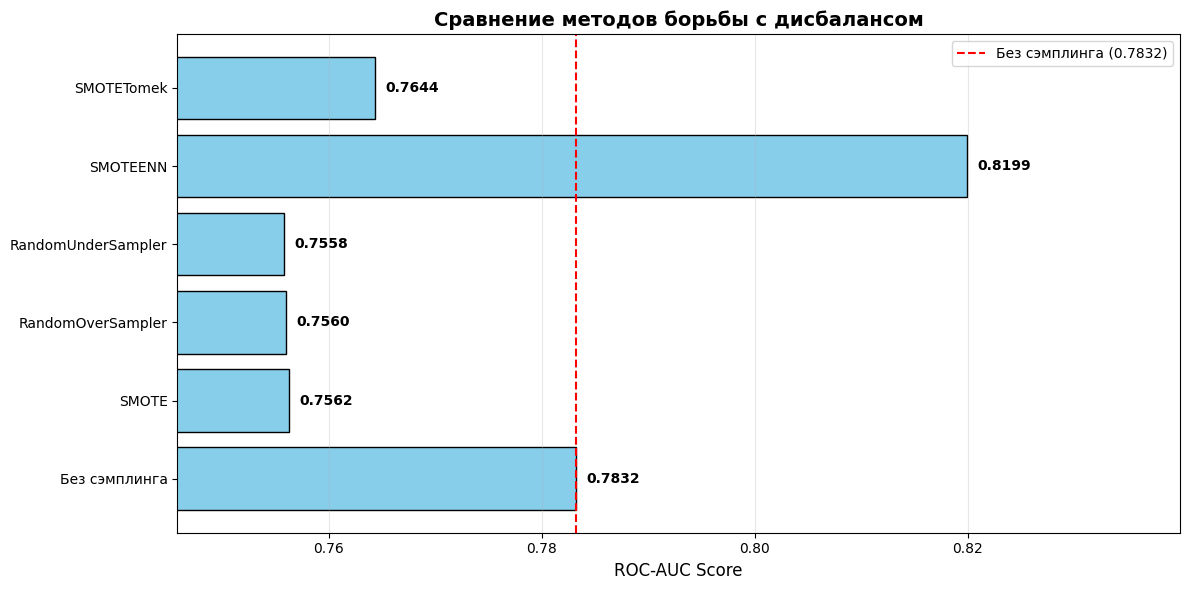


ПРИМЕНЕНИЕ ЛУЧШЕГО МЕТОДА: SMOTEENN
Используем сэмплер: SMOTEENN
Сэмплер будет применяться внутри пайплайна во время обучения


In [ ]:
print("\n" + "="*60)
print("СРАВНЕНИЕ МЕТОДОВ БОРЬБЫ С ДИСБАЛАНСОМ")
print("="*60)

# Простой классификатор для тестирования
base_model = LogisticRegression(max_iter=1000, random_state=42, solver='saga')

sampling_results = {}
best_sampler_object = None

for method_name, sampler in sampling_methods.items():
    if sampler is None:
        # Без сэмплинга
        X_resampled = X_train_processed.copy()
        y_resampled = y_train.copy()
    else:
        # Применяем сэмплинг
        X_resampled, y_resampled = sampler.fit_resample(X_train_processed, y_train)

    print(f"\n{method_name}:")
    print(f"  Размер выборки: {X_resampled.shape[0]} записей")
    print(f"  Распределение классов: {np.bincount(y_resampled)}")

    # Оценка с кросс-валидацией
    cv_scores = cross_val_score(
        base_model, X_resampled, y_resampled,
        cv=3, scoring='roc_auc', n_jobs=-1
    )

    mean_score = cv_scores.mean()
    std_score = cv_scores.std()
    sampling_results[method_name] = {
        'score': mean_score,
        'std': std_score,
        'sampler': sampler
    }

    print(f"  ROC-AUC: {mean_score:.4f} (+/- {std_score:.4f})")

# Вывод лучшего метода
best_method = max(sampling_results, key=lambda x: sampling_results[x]['score'])
best_score = sampling_results[best_method]['score']
best_sampler_object = sampling_methods[best_method]

print(f"\n{'='*60}")
print(f"ЛУЧШИЙ МЕТОД: {best_method}")
print(f"ROC-AUC: {best_score:.4f}")
print("="*60)

# Визуализация результатов
plt.figure(figsize=(12, 6))
methods = list(sampling_results.keys())
scores = [sampling_results[m]['score'] for m in methods]

bars = plt.barh(methods, scores, color='skyblue', edgecolor='black')
plt.axvline(x=sampling_results['Без сэмплинга']['score'], color='red', linestyle='--',
            label=f'Без сэмплинга ({sampling_results["Без сэмплинга"]["score"]:.4f})')

# Добавляем значения
for bar, score in zip(bars, scores):
    plt.text(score + 0.001, bar.get_y() + bar.get_height()/2,
             f'{score:.4f}', va='center', fontweight='bold')

plt.xlabel('ROC-AUC Score', fontsize=12)
plt.title('Сравнение методов борьбы с дисбалансом', fontsize=14, fontweight='bold')
plt.xlim([min(scores)-0.01, max(scores)+0.02])
plt.legend()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print(f"ПРИМЕНЕНИЕ ЛУЧШЕГО МЕТОДА: {best_method}")
print("="*60)

best_sampler = best_sampler_object
print(f"Используем сэмплер: {best_method}")
print(f"Сэмплер будет применяться внутри пайплайна во время обучения")

## Создание функций

### Пайплайн

In [ ]:
def create_full_pipeline(model, sampler=None, use_feature_engineering=False):
    pipeline_steps = []

    # 1. Preprocessor
    pipeline_steps.append(('preprocessor', DataPreprocessor()))

    # 2. Feature Engineering
    if use_feature_engineering:
        pipeline_steps.append(('feature_engineer', FeatureEngineer(add_features=True)))

    # 3. Сэмплер
    if sampler is not None:
        pipeline_steps.append(('sampler', SamplingTransformer(sampler)))

    # 4. Моджель
    pipeline_steps.append(('model', model))

    pipeline = ImbPipeline(steps=pipeline_steps)
    return pipeline

### Обучения модели

In [ ]:
def train_model_with_config(model_config, X_train_raw, y_train, X_test_raw, y_test):

    model_name = model_config['name']
    print(f"\n{'='*60}")
    print(f"ОБУЧЕНИЕ: {model_name}")
    print(f"{'='*60}")

    try:
        # Создаем пайплайн
        pipeline = create_full_pipeline(
            model=model_config['model'],
            sampler=model_config.get('sampler'),
            use_feature_engineering=model_config.get('use_fe', False)
        )

        # Проверяем размеры данных
        print(f"Размер X_train_raw: {X_train_raw.shape}")
        print(f"Размер y_train: {y_train.shape}")

        # Кросс-валидация
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

        cv_results = cross_validate(
            pipeline,
            X_train_raw,
            y_train,
            cv=skf,
            scoring=['roc_auc'],
            return_train_score=False,
            n_jobs=-1,
            error_score='raise'
        )

        print(f"CV AUC: {cv_results['test_roc_auc'].mean():.4f} (±{cv_results['test_roc_auc'].std():.4f})")

        # Обучение на всех данных
        print("Обучение на полном наборе данных...")
        pipeline.fit(X_train_raw, y_train)

        # Оценка на тесте
        y_pred_proba = pipeline.predict_proba(X_test_raw)[:, 1]
        test_auc = roc_auc_score(y_test, y_pred_proba)
        print(f"Test AUC: {test_auc:.4f}")

        # Расчет прибыли
        Loss_Default = 10000
        Loss_RejectGood = 500
        Profit_Good = 800

        # Поиск оптимального порога
        y_pred_proba_train = pipeline.predict_proba(X_train_raw)[:, 1]
        thresholds = np.linspace(0.1, 0.9, 50)
        profits = []

        for thr in thresholds:
            y_pred = (y_pred_proba_train >= thr).astype(int)
            tn, fp, fn, tp = confusion_matrix(y_train, y_pred).ravel()
            profit = (tn * Profit_Good) - (fn * Loss_Default) - (fp * Loss_RejectGood)
            profits.append(profit)

        best_threshold = thresholds[np.argmax(profits)]
        best_profit = max(profits)

        print(f"Оптимальный порог: {best_threshold:.3f}")
        print(f"Прибыль на train: ${best_profit:,.0f}")

        # Применяем порог к тесту
        y_pred_test = (y_pred_proba >= best_threshold).astype(int)
        tn_test, fp_test, fn_test, tp_test = confusion_matrix(y_test, y_pred_test).ravel()
        profit_test = (tn_test * Profit_Good) - (fn_test * Loss_Default) - (fp_test * Loss_RejectGood)

        print(f"Прибыль на test: ${profit_test:,.0f}")

        # Feature Importance
        feature_importance = None
        if hasattr(pipeline.named_steps['model'], 'feature_importances_'):
            feature_importance = pipeline.named_steps['model'].feature_importances_
        elif hasattr(pipeline.named_steps['model'], 'coef_'):
            feature_importance = np.abs(pipeline.named_steps['model'].coef_[0])

        # Получаем имена признаков
        try:
            temp_pipeline = ImbPipeline(steps=pipeline.steps[:-1])
            temp = temp_pipeline.fit_transform(X_train_raw.head(1), y_train.head(1))

            if isinstance(temp, np.ndarray):
                feature_names = [f'feature_{i}' for i in range(temp.shape[1])]
            else:
                feature_names = temp.columns.tolist()

            print(f"Количество признаков после преобразований: {len(feature_names)}")

        except Exception as e:
            print(f"Не удалось получить имена признаков: {e}")
            feature_names = list(range(X_train_raw.shape[1]))

        # Анализ Feature Importance
        fi_analysis = None
        if feature_importance is not None:
            fi_analysis = analyze_feature_importance(
                feature_importance,
                feature_names,
                model_name
            )

        return {
            'name': model_name,
            'pipeline': pipeline,
            'cv_auc_mean': cv_results['test_roc_auc'].mean(),
            'cv_auc_std': cv_results['test_roc_auc'].std(),
            'test_auc': test_auc,
            'best_threshold': best_threshold,
            'train_profit': best_profit,
            'test_profit': profit_test,
            'feature_importance': feature_importance,
            'feature_names': feature_names,
            'fi_analysis': fi_analysis,
            'y_pred_proba': y_pred_proba,
            'y_pred': y_pred_test
        }

    except Exception as e:
        print(f"Ошибка при обучении {model_name}: {str(e)}")
        import traceback
        traceback.print_exc()
        return None

### Анализ Feature Importance

In [ ]:
def analyze_feature_importance(feature_importance, feature_names, model_name):

    if feature_importance is None:
        print(f"\nМодель {model_name} не поддерживает feature importance")
        return None

    # Создаем DataFrame
    importance_df = pd.DataFrame({
        'Признак': feature_names,
        'Важность': feature_importance
    }).sort_values('Важность', ascending=False)

    print(f"\n{'='*80}")
    print(f"АНАЛИЗ FEATURE IMPORTANCE: {model_name}")
    print("="*80)

    # Топ-5 признаков
    print("\nТОП-5 САМЫХ ВАЖНЫХ ПРИЗНАКОВ:")
    print("-" * 60)

    total_importance = importance_df['Важность'].sum()

    cumulative_percent = 0

    for idx, (index, row) in enumerate(importance_df.head(5).iterrows(), start=1):
        importance_percent = (row['Важность'] / total_importance) * 100
        cumulative_percent += importance_percent
        print(f"{idx:2d}. {row['Признак']:35s}: {row['Важность']:.4f} ({importance_percent:.1f}%)")

    print(f"\nКумулятивный вклад топ-5 признаков: {cumulative_percent:.1f}%")

    top5_total = importance_df.head(5)['Важность'].sum()
    top5_percent = (top5_total / total_importance) * 100
    print(f"Итоговый вклад топ-5 признаков: {top5_percent:.1f}%")

    cumulative = 0
    for i, row in importance_df.iterrows():
        cumulative += row['Важность']
        cumulative_percent_all = (cumulative / importance_df['Важность'].sum()) * 100
        if cumulative_percent_all >= 80 and cumulative_percent_all - (row['Важность']/total_importance*100) < 80:
            print(f"\n80% вклада достигается после {i+1} признаков")
            print(f"Можно упростить модель, используя только {i+1} самых важных признаков")
            break

    # Группировка по типам признаков
    feature_categories = {
        'Кредитные параметры': ['loan_int_rate', 'loan_grade', 'loan_percent_income', 'loan_amnt'],
        'Финансовые': ['person_income', 'loan_to_income'],
        'Демографические': ['person_age', 'person_emp_length'],
        'Кредитная история': ['cb_person_default_on_file', 'cb_person_cred_hist_length'],
        'Производные признаки': ['log_income', 'log_loan_amnt', 'credit_history_to_age', 'emp_length_to_age']
    }

    category_importance = {}
    for category, features in feature_categories.items():
        cat_importance = 0
        for feature in features:
            if feature in importance_df['Признак'].values:
                cat_importance += importance_df.loc[importance_df['Признак'] == feature, 'Важность'].values[0]
        category_importance[category] = cat_importance

    print(f"\nВКЛАД КАТЕГОРИЙ ПРИЗНАКОВ:")
    print("-" * 60)
    for category, importance in sorted(category_importance.items(), key=lambda x: x[1], reverse=True):
        percent = (importance / importance_df['Важность'].sum()) * 100
        print(f"  • {category:25s}: {percent:.1f}%")

    return importance_df

### Упрощенная модель на основе FI

In [ ]:
def create_simplified_model_based_on_fi(best_model_info, X_train_raw, y_train, X_test_raw, y_test):

    if best_model_info['fi_analysis'] is None:
        print("Невозможно создать упрощенную модель: нет данных о важности признаков")
        return None

    importance_df = best_model_info['fi_analysis']

    n_features = 5
    top_features = importance_df.head(n_features)['Признак'].tolist()

    print(f"\nТОП-{n_features} самых важных признаков:")
    print("-" * 60)

    total_importance = importance_df['Важность'].sum()
    top5_total = importance_df.head(n_features)['Важность'].sum()
    top5_percent = (top5_total / total_importance) * 100

    for idx, (index, row) in enumerate(importance_df.head(n_features).iterrows(), start=1):
        importance_percent = (row['Важность'] / total_importance) * 100
        print(f"{idx:2d}. {row['Признак']:35s}: {row['Важность']:.4f} ({importance_percent:.1f}%)")

    print(f"\nИтоговый вклад топ-{n_features} признаков: {top5_percent:.1f}%")
    print(f"Можно упростить модель с {len(importance_df)} до {n_features} признаков")


    feature_names = best_model_info['feature_names']
    feature_indices = []

    for top_feature in top_features:
        for i, feature in enumerate(feature_names):
            if top_feature == feature or top_feature in feature:
                feature_indices.append(i)
                break

    print(f"\nИндексы выбранных признаков: {feature_indices}")
    print(f"Имена выбранных признаков: {[feature_names[i] for i in feature_indices]}")

    from sklearn.compose import ColumnTransformer

    column_selector = ColumnTransformer(
        [('selector', 'passthrough', feature_indices)],
        remainder='drop'
    )

    original_pipeline = best_model_info['pipeline']

    simplified_steps = []

    for step_name, step_transformer in original_pipeline.steps[:-1]:
        simplified_steps.append((step_name, step_transformer))

    simplified_steps.append(('column_selector', column_selector))

    model_type = type(original_pipeline.named_steps['model'])
    model_params = original_pipeline.named_steps['model'].get_params()
    simplified_steps.append(('model', model_type(**model_params)))

    simplified_pipeline = ImbPipeline(steps=simplified_steps)

    # Обучаем упрощенную модель
    print(f"\nОбучение упрощенной модели на {len(feature_indices)} признаках...")
    simplified_pipeline.fit(X_train_raw, y_train)

    # Сравниваем с оригинальной моделью
    y_pred_original = best_model_info['pipeline'].predict_proba(X_test_raw)[:, 1]
    y_pred_simple = simplified_pipeline.predict_proba(X_test_raw)[:, 1]

    original_auc = roc_auc_score(y_test, y_pred_original)
    simple_auc = roc_auc_score(y_test, y_pred_simple)

    print(f"\nСРАВНЕНИЕ МОДЕЛЕЙ:")
    print("-" * 50)
    print(f"  Оригинальная модель ({len(feature_names)} признаков):")
    print(f"    AUC = {original_auc:.4f}")
    print(f"    Прибыль на тесте = ${best_model_info['test_profit']:,.0f}")

    print(f"\n  Упрощенная модель ({len(feature_indices)} признаков):")
    print(f"    AUC = {simple_auc:.4f}")

    # Вычисляем прибыль для упрощенной модели
    y_pred_simple_class = (y_pred_simple >= best_model_info['best_threshold']).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_simple_class).ravel()
    profit_simple = (tn * 800) - (fn * 10000) - (fp * 500)
    print(f"    Прибыль на тесте = ${profit_simple:,.0f}")

    print(f"\n  Разница в качестве:")
    print(f"    AUC: {simple_auc - original_auc:+.4f}")
    print(f"    Прибыль: ${profit_simple - best_model_info['test_profit']:+,.0f}")

    quality_ratio = (simple_auc / original_auc) * 100
    if simple_auc >= original_auc * 0.95:
        print(f"\n Упрощенная модель сохраняет {quality_ratio:.1f}% качества!")
        print(f"   Рекомендуется использовать упрощенную модель")
    else:
        print(f"\n Упрощенная модель теряет {100 - quality_ratio:.1f}% качества")
        print(f"   Рекомендуется использовать полную модель")

    return simplified_pipeline

### Визуализации FI

In [ ]:
def plot_feature_importance(feature_importance, feature_names, model_name, top_n=20):

    if feature_importance is None:
        print(f"\nМодель {model_name} не поддерживает feature importance")
        return

    importance_df = pd.DataFrame({
        'feature': feature_names,
        'importance': feature_importance
    })

    importance_df = importance_df.sort_values('importance', ascending=False).head(top_n)

    # Визуализация
    plt.figure(figsize=(12, 8))
    bars = plt.barh(range(len(importance_df)), importance_df['importance'].values)
    plt.yticks(range(len(importance_df)), importance_df['feature'].values)
    plt.xlabel('Важность признака', fontsize=12)
    plt.title(f'Feature Importance - {model_name} (Top {top_n})', fontsize=14, fontweight='bold')
    plt.gca().invert_yaxis()

    for i, (bar, importance) in enumerate(zip(bars, importance_df['importance'].values)):
        plt.text(importance * 1.01, i, f'{importance:.4f}', va='center', fontsize=10)

    plt.tight_layout()
    plt.show()

    return importance_df

### Визуализации ROC Curve

In [ ]:
def plot_roc_and_metrics(y_true, y_pred_proba, model_name, dataset_name='Test', optimal_threshold=None):

    fig = plt.figure(figsize=(18, 5))
    fig.suptitle(f'{model_name} - {dataset_name} Data', fontsize=16, fontweight='bold')

    # ROC-Curve
    ax1 = plt.subplot(1, 4, 1)
    fpr, tpr, thresholds = roc_curve(y_true, y_pred_proba)
    roc_auc_value = roc_auc_score(y_true, y_pred_proba)

    ax1.plot(fpr, tpr, color='darkorange', lw=2,
             label=f'ROC curve (AUC = {roc_auc_value:.4f})')
    ax1.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', alpha=0.5, label='Random')

    if optimal_threshold is not None:
        idx = np.argmin(np.abs(thresholds - optimal_threshold))
        ax1.scatter(fpr[idx], tpr[idx], color='red', s=100,
                   label=f'Threshold: {optimal_threshold:.3f}')
        ax1.annotate(f'({fpr[idx]:.3f}, {tpr[idx]:.3f})',
                    xy=(fpr[idx], tpr[idx]),
                    xytext=(fpr[idx] + 0.05, tpr[idx] - 0.05),
                    fontsize=9)

    ax1.set_xlim([0.0, 1.0])
    ax1.set_ylim([0.0, 1.05])
    ax1.set_xlabel('False Positive Rate', fontsize=11)
    ax1.set_ylabel('True Positive Rate', fontsize=11)
    ax1.set_title('ROC Curve', fontsize=13)
    ax1.legend(loc="lower right", fontsize=9)
    ax1.grid(alpha=0.3)

    # Precision-Recall Curve
    ax2 = plt.subplot(1, 4, 2)
    precision, recall, _ = precision_recall_curve(y_true, y_pred_proba)
    pr_auc_value = np.trapezoid(precision, recall)

    ax2.plot(recall, precision, color='green', lw=2,
             label=f'PR curve (AUC = {pr_auc_value:.4f})')

    # Базовая линия - доля положительных классов
    baseline = sum(y_true) / len(y_true)
    ax2.axhline(y=baseline, color='navy', linestyle='--', alpha=0.5,
                label=f'Baseline: {baseline:.3f}')

    if optimal_threshold is not None:
        y_pred = (y_pred_proba >= optimal_threshold).astype(int)
        prec = precision_score(y_true, y_pred, zero_division=0)
        rec = recall_score(y_true, y_pred, zero_division=0)
        ax2.scatter(rec, prec, color='red', s=100,
                   label=f'Threshold: {optimal_threshold:.3f}')
        ax2.annotate(f'({rec:.3f}, {prec:.3f})',
                    xy=(rec, prec),
                    xytext=(rec + 0.05, prec - 0.05),
                    fontsize=9)

    ax2.set_xlim([0.0, 1.0])
    ax2.set_ylim([0.0, 1.05])
    ax2.set_xlabel('Recall', fontsize=11)
    ax2.set_ylabel('Precision', fontsize=11)
    ax2.set_title('Precision-Recall Curve', fontsize=13)
    ax2.legend(loc="lower left", fontsize=9)
    ax2.grid(alpha=0.3)

    # Распределение вероятностей
    ax3 = plt.subplot(1, 4, 3)

    prob_class_0 = y_pred_proba[y_true == 0]
    prob_class_1 = y_pred_proba[y_true == 1]

    ax3.hist(prob_class_0, bins=30, alpha=0.6, label='Class 0 (Negative)',
             color='blue', density=True, edgecolor='black')
    ax3.hist(prob_class_1, bins=30, alpha=0.6, label='Class 1 (Positive)',
             color='red', density=True, edgecolor='black')

    if optimal_threshold is not None:
        ax3.axvline(x=optimal_threshold, color='green', linestyle='--', lw=2,
                   label=f'Threshold: {optimal_threshold:.3f}')

    ax3.set_xlabel('Predicted Probability', fontsize=11)
    ax3.set_ylabel('Density', fontsize=11)
    ax3.set_title('Probability Distribution', fontsize=13)
    ax3.legend(loc="upper right", fontsize=9)
    ax3.grid(alpha=0.3)

    # Метрики в текстовом виде
    ax4 = plt.subplot(1, 4, 4)
    ax4.axis('off')

    if optimal_threshold is not None:
        y_pred = (y_pred_proba >= optimal_threshold).astype(int)

        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

        accuracy = (tp + tn) / (tp + tn + fp + fn)
        precision_val = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall_val = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * (precision_val * recall_val) / (precision_val + recall_val) if (precision_val + recall_val) > 0 else 0

        metrics_text = (
            f"Optimal Threshold: {optimal_threshold:.3f}\n\n"
            f"ROC AUC: {roc_auc_value:.4f}\n"
            f"PR AUC: {pr_auc_value:.4f}\n\n"
            f"Accuracy: {accuracy:.4f}\n"
            f"Precision: {precision_val:.4f}\n"
            f"Recall: {recall_val:.4f}\n"
            f"F1-Score: {f1:.4f}\n\n"
            f"Confusion Matrix:\n"
            f"TN: {tn}, FP: {fp}\n"
            f"FN: {fn}, TP: {tp}"
        )
    else:
        metrics_text = (
            f"ROC AUC: {roc_auc_value:.4f}\n"
            f"PR AUC: {pr_auc_value:.4f}\n\n"
            f"Class Distribution:\n"
            f"Class 0: {len(prob_class_0)}\n"
            f"Class 1: {len(prob_class_1)}"
        )

    ax4.text(0.1, 0.5, metrics_text, fontsize=10, family='monospace',
             verticalalignment='center', transform=ax4.transAxes,
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

    plt.tight_layout()
    plt.show()

### Визуализации Порога

In [ ]:
def plot_profit_vs_threshold(y_true, y_pred_proba, Loss_Default=10000,
                            Loss_RejectGood=500, Profit_Good=800):

    thresholds = np.linspace(0.01, 0.99, 100)
    profits = []

    for thr in thresholds:
        y_pred = (y_pred_proba >= thr).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
        profit = (tn * Profit_Good) - (fn * Loss_Default) - (fp * Loss_RejectGood)
        profits.append(profit)

    best_threshold = thresholds[np.argmax(profits)]
    best_profit = max(profits)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    # График прибыли
    ax1.plot(thresholds, profits, 'b-', linewidth=2, label='Profit')
    ax1.axvline(x=best_threshold, color='r', linestyle='--',
               label=f'Optimal: {best_threshold:.3f}')
    ax1.scatter(best_threshold, best_profit, color='red', s=100, zorder=5)

    ax1.annotate(f'Max: ${best_profit:,.0f}\nThreshold: {best_threshold:.3f}',
                xy=(best_threshold, best_profit),
                xytext=(best_threshold + 0.1, best_profit * 0.9),
                arrowprops=dict(arrowstyle='->', color='red'),
                fontsize=12, fontweight='bold')

    ax1.set_xlabel('Classification Threshold', fontsize=12)
    ax1.set_ylabel('Profit ($)', fontsize=12)
    ax1.set_title('Profit vs Classification Threshold', fontsize=14)
    ax1.legend(loc="best")
    ax1.grid(alpha=0.3)

    # Метрики для оптимального порога
    y_pred_optimal = (y_pred_proba >= best_threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred_optimal).ravel()

    cm = np.array([[tn, fp], [fn, tp]])
    im = ax2.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    ax2.figure.colorbar(im, ax=ax2)

    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax2.text(j, i, format(cm[i, j], 'd'),
                    ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black",
                    fontsize=14, fontweight='bold')

    ax2.set_xticks([0, 1])
    ax2.set_yticks([0, 1])
    ax2.set_xticklabels(['Predicted 0', 'Predicted 1'])
    ax2.set_yticklabels(['Actual 0', 'Actual 1'])
    ax2.set_ylabel('True Label', fontsize=12)
    ax2.set_xlabel('Predicted Label', fontsize=12)
    ax2.set_title(f'Confusion Matrix\nThreshold: {best_threshold:.3f}', fontsize=14)

    accuracy_val = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) > 0 else 0
    precision_val = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall_val = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1_val = 2 * tp / (2 * tp + fp + fn) if (2 * tp + fp + fn) > 0 else 0

    metrics_text = (
        f"Accuracy: {accuracy_val:.3f}\n"
        f"Precision: {precision_val:.3f}\n"
        f"Recall: {recall_val:.3f}\n"
        f"F1-Score: {f1_val:.3f}"
    )

    ax2.text(2.2, 0.5, metrics_text, fontsize=11,
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
             transform=ax2.transAxes)

    plt.tight_layout()
    plt.show()

    return best_threshold, best_profit

## Обучение базовых моделей

Конфиг для моделей

Можно менять показатели в конфиге для улучшения качества обучения

In [ ]:
model_configs = [
    # Базовые модели (без FE)
    {
        'name': 'Logistic Regression',
        'model': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
        'sampler': best_sampler,
        'use_fe': False
    },
    {
        'name': 'LinearSVC',
        'model': CalibratedClassifierCV(LinearSVC(tol=1e-5, max_iter=2000, random_state=42)),
        'sampler': None,
        'use_fe': False
    },
    {
        'name': 'Decision Tree',
        'model': tree.DecisionTreeClassifier(max_depth=10, random_state=42),
        'sampler': best_sampler,
        'use_fe': False
    },
    {
        'name': 'Random Forest',
        'model': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
        'sampler': best_sampler,
        'use_fe': False
    },
    {
        'name': 'XGBoost',
        'model': xgb.XGBClassifier(random_state=42, verbosity=0),
        'sampler': best_sampler,
        'use_fe': False
    },
    {
        'name': 'CatBoost',
        'model': CatBoostClassifier(iterations=100, verbose=False, random_state=42),
        'sampler': best_sampler,
        'use_fe': False
    },

    # Модели с FE
    {
        'name': 'Logistic Regression (FE)',
        'model': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
        'sampler': best_sampler,
        'use_fe': True
    },
    {
        'name': 'LinearSVC (FE)',
        'model': CalibratedClassifierCV(LinearSVC(tol=1e-5, max_iter=2000, random_state=42)),
        'sampler': None,
        'use_fe': True
    },
    {
        'name': 'Decision Tree (FE)',
        'model': tree.DecisionTreeClassifier(max_depth=10, random_state=42),
        'sampler': best_sampler,
        'use_fe': True
    },
    {
        'name': 'Random Forest (FE)',
        'model': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
        'sampler': best_sampler,
        'use_fe': True
    },
    {
        'name': 'XGBoost (FE)',
        'model': xgb.XGBClassifier(random_state=42, verbosity=0),
        'sampler': best_sampler,
        'use_fe': True
    },
    {
        'name': 'CatBoost (FE)',
        'model': CatBoostClassifier(iterations=100, verbose=False, random_state=42),
        'sampler': best_sampler,
        'use_fe': True
    }
]

Одна модель для всего  
Данные моделей тянутся из конфига  
Feature Engeeniring и Feature Importance берутся из заранее написанных функций


НАЧАЛО ОБУЧЕНИЯ ВСЕХ МОДЕЛЕЙ С АНАЛИЗОМ FEATURE IMPORTANCE

МОДЕЛЬ: Logistic Regression

ОБУЧЕНИЕ: Logistic Regression
Размер X_train_raw: (43981, 11)
Размер y_train: (43981,)
CV AUC: 0.8713 (±0.0045)
Обучение на полном наборе данных...
Test AUC: 0.8714
Оптимальный порог: 0.492
Прибыль на train: $7,896,400
Прибыль на test: $2,519,500
Количество признаков после преобразований: 11

АНАЛИЗ FEATURE IMPORTANCE: Logistic Regression

ТОП-5 САМЫХ ВАЖНЫХ ПРИЗНАКОВ:
------------------------------------------------------------
 1. loan_grade                         : 1.2668 (60.0%)
 2. person_home_ownership              : 0.2769 (13.1%)
 3. cb_person_default_on_file          : 0.1631 (7.7%)
 4. loan_int_rate                      : 0.1419 (6.7%)
 5. loan_intent                        : 0.1154 (5.5%)

Кумулятивный вклад топ-5 признаков: 93.0%
Итоговый вклад топ-5 признаков: 93.0%

80% вклада достигается после 10 признаков
Можно упростить модель, используя только 10 самых важных признаков

ВКЛАД КА

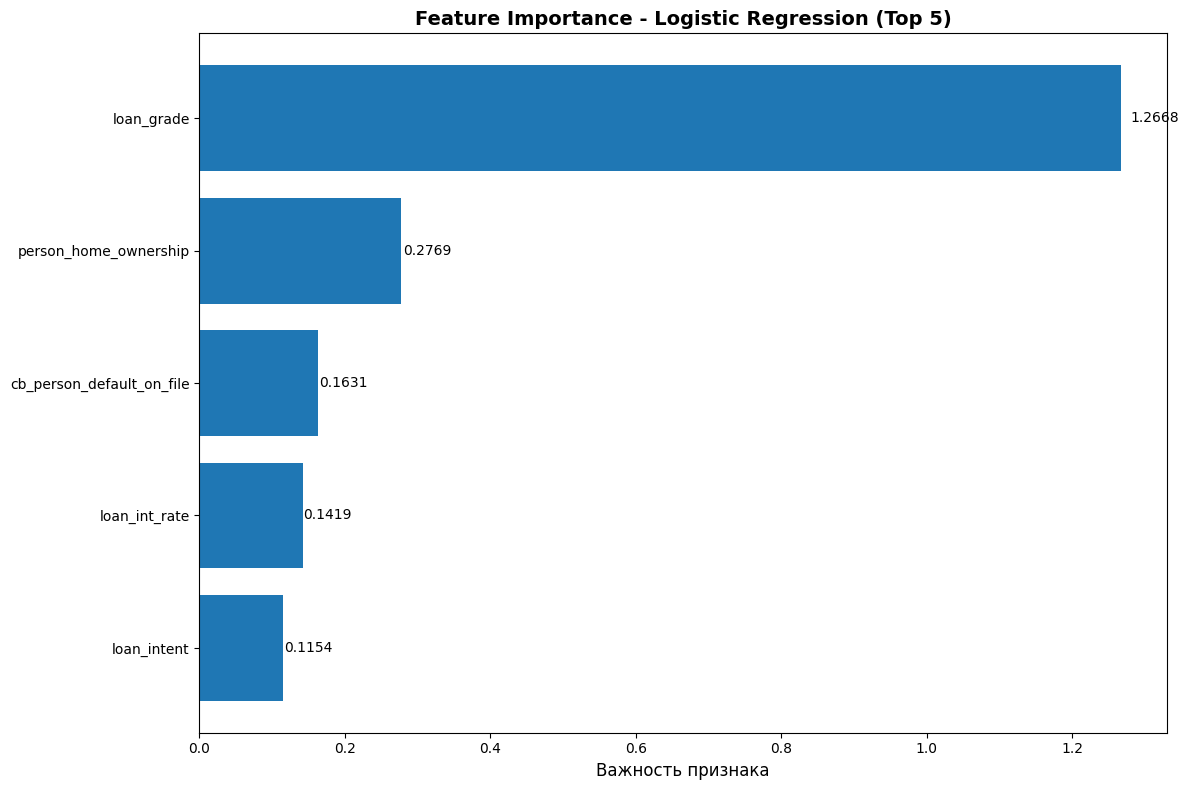


МОДЕЛЬ: LinearSVC

ОБУЧЕНИЕ: LinearSVC
Размер X_train_raw: (43981, 11)
Размер y_train: (43981,)
CV AUC: 0.8667 (±0.0045)
Обучение на полном наборе данных...
Test AUC: 0.8680
Оптимальный порог: 0.149
Прибыль на train: $7,647,900
Прибыль на test: $2,444,500
Количество признаков после преобразований: 11
LinearSVC не поддерживает Feature Importance

МОДЕЛЬ: Decision Tree

ОБУЧЕНИЕ: Decision Tree
Размер X_train_raw: (43981, 11)
Размер y_train: (43981,)
CV AUC: 0.8951 (±0.0048)
Обучение на полном наборе данных...
Test AUC: 0.9069
Оптимальный порог: 0.116
Прибыль на train: $16,173,800
Прибыль на test: $4,365,900
Количество признаков после преобразований: 11

АНАЛИЗ FEATURE IMPORTANCE: Decision Tree

ТОП-5 САМЫХ ВАЖНЫХ ПРИЗНАКОВ:
------------------------------------------------------------
 1. loan_percent_income                : 0.3268 (32.7%)
 2. loan_grade                         : 0.2509 (25.1%)
 3. person_home_ownership              : 0.1828 (18.3%)
 4. loan_intent                       

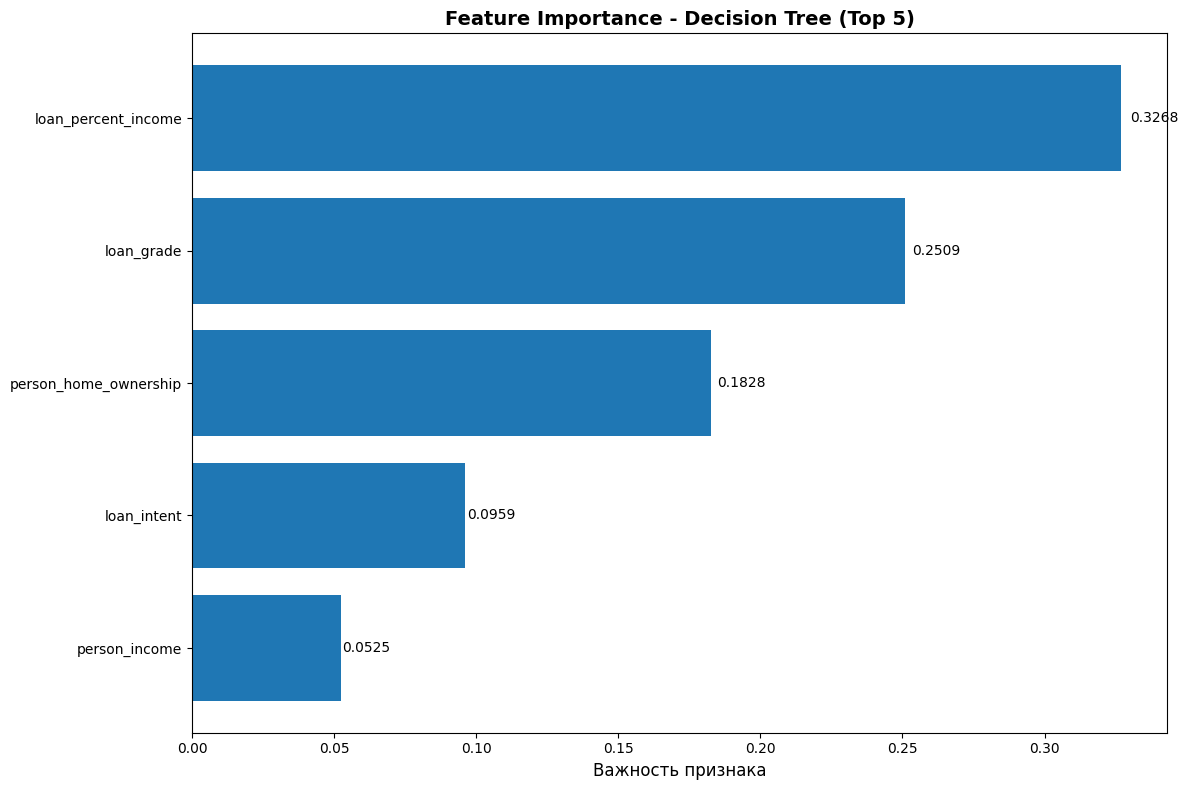


МОДЕЛЬ: Random Forest

ОБУЧЕНИЕ: Random Forest
Размер X_train_raw: (43981, 11)
Размер y_train: (43981,)
CV AUC: 0.9328 (±0.0031)
Обучение на полном наборе данных...
Test AUC: 0.9327
Оптимальный порог: 0.476
Прибыль на train: $30,175,200
Прибыль на test: $3,712,800
Количество признаков после преобразований: 11

АНАЛИЗ FEATURE IMPORTANCE: Random Forest

ТОП-5 САМЫХ ВАЖНЫХ ПРИЗНАКОВ:
------------------------------------------------------------
 1. loan_percent_income                : 0.2388 (23.9%)
 2. loan_int_rate                      : 0.1364 (13.6%)
 3. loan_grade                         : 0.1214 (12.1%)
 4. person_income                      : 0.1143 (11.4%)
 5. person_home_ownership              : 0.0918 (9.2%)

Кумулятивный вклад топ-5 признаков: 70.3%
Итоговый вклад топ-5 признаков: 70.3%

80% вклада достигается после 5 признаков
Можно упростить модель, используя только 5 самых важных признаков

ВКЛАД КАТЕГОРИЙ ПРИЗНАКОВ:
----------------------------------------------------------

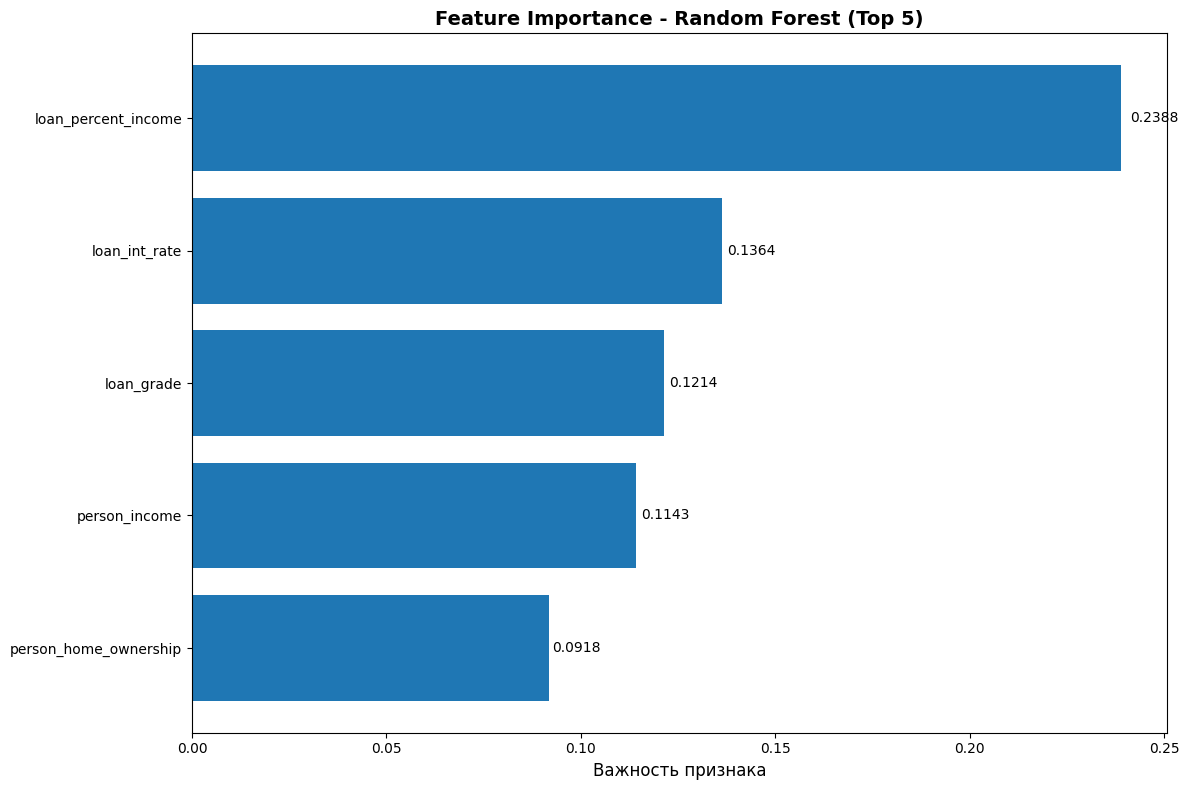


МОДЕЛЬ: XGBoost

ОБУЧЕНИЕ: XGBoost
Размер X_train_raw: (43981, 11)
Размер y_train: (43981,)
CV AUC: 0.9502 (±0.0025)
Обучение на полном наборе данных...
Test AUC: 0.9547
Оптимальный порог: 0.133
Прибыль на train: $24,493,700
Прибыль на test: $5,672,600
Количество признаков после преобразований: 11

АНАЛИЗ FEATURE IMPORTANCE: XGBoost

ТОП-5 САМЫХ ВАЖНЫХ ПРИЗНАКОВ:
------------------------------------------------------------
 1. loan_grade                         : 0.5209 (52.1%)
 2. person_home_ownership              : 0.1778 (17.8%)
 3. loan_percent_income                : 0.1331 (13.3%)
 4. loan_intent                        : 0.0534 (5.3%)
 5. person_income                      : 0.0324 (3.2%)

Кумулятивный вклад топ-5 признаков: 91.8%
Итоговый вклад топ-5 признаков: 91.8%

80% вклада достигается после 9 признаков
Можно упростить модель, используя только 9 самых важных признаков

ВКЛАД КАТЕГОРИЙ ПРИЗНАКОВ:
------------------------------------------------------------
  • Кредитные па

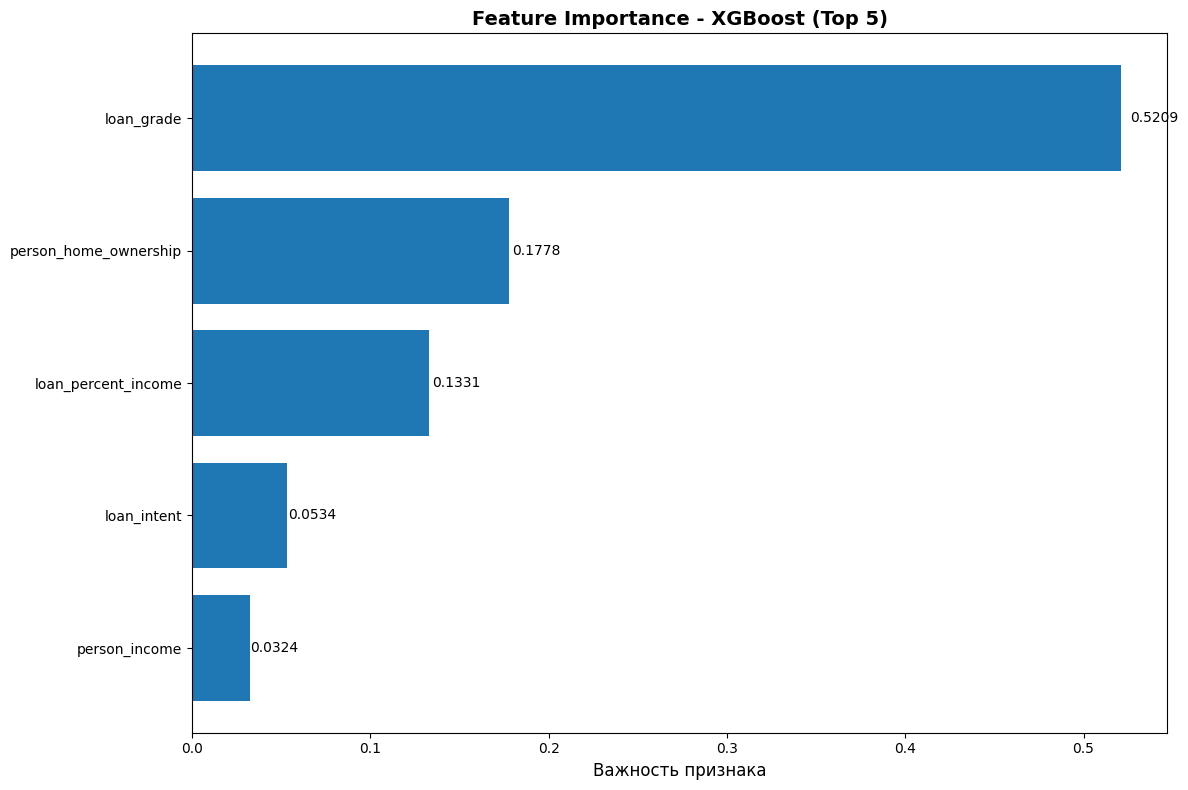


МОДЕЛЬ: CatBoost

ОБУЧЕНИЕ: CatBoost
Размер X_train_raw: (43981, 11)
Размер y_train: (43981,)
CV AUC: 0.9509 (±0.0030)
Обучение на полном наборе данных...
Test AUC: 0.9508
Оптимальный порог: 0.116
Прибыль на train: $18,794,700
Прибыль на test: $5,624,600
Количество признаков после преобразований: 11

АНАЛИЗ FEATURE IMPORTANCE: CatBoost

ТОП-5 САМЫХ ВАЖНЫХ ПРИЗНАКОВ:
------------------------------------------------------------
 1. person_income                      : 21.6791 (21.7%)
 2. loan_percent_income                : 17.4312 (17.4%)
 3. loan_intent                        : 15.2701 (15.3%)
 4. loan_grade                         : 13.5884 (13.6%)
 5. person_home_ownership              : 12.9242 (12.9%)

Кумулятивный вклад топ-5 признаков: 80.9%
Итоговый вклад топ-5 признаков: 80.9%

80% вклада достигается после 3 признаков
Можно упростить модель, используя только 3 самых важных признаков

ВКЛАД КАТЕГОРИЙ ПРИЗНАКОВ:
------------------------------------------------------------
  • Кр

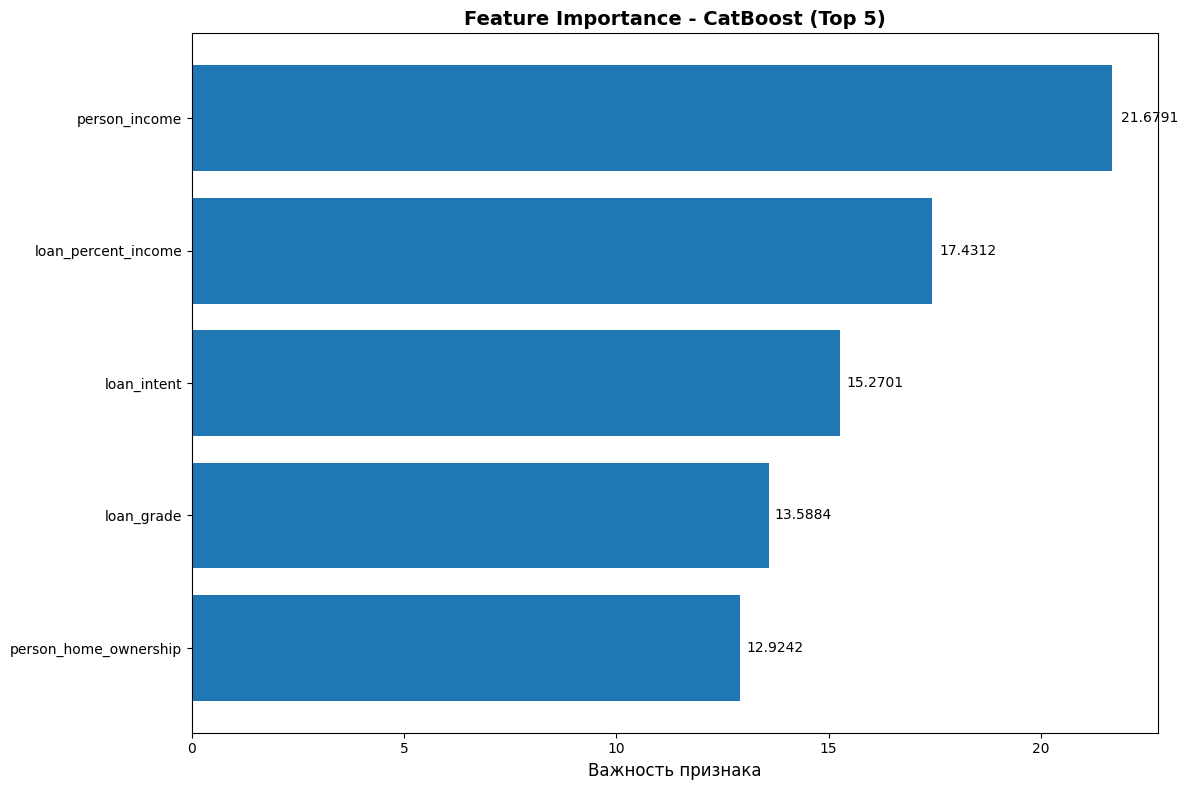


МОДЕЛЬ: Logistic Regression (FE)

ОБУЧЕНИЕ: Logistic Regression (FE)
Размер X_train_raw: (43981, 11)
Размер y_train: (43981,)
CV AUC: 0.8724 (±0.0028)
Обучение на полном наборе данных...
Test AUC: 0.8693
Оптимальный порог: 0.427
Прибыль на train: $6,983,600
Прибыль на test: $2,147,200
Количество признаков после преобразований: 17

АНАЛИЗ FEATURE IMPORTANCE: Logistic Regression (FE)

ТОП-5 САМЫХ ВАЖНЫХ ПРИЗНАКОВ:
------------------------------------------------------------
 1. loan_grade                         : 0.4091 (27.6%)
 2. person_home_ownership              : 0.3422 (23.1%)
 3. log_income                         : 0.2047 (13.8%)
 4. log_loan_amnt                      : 0.1330 (9.0%)
 5. loan_int_rate                      : 0.1293 (8.7%)

Кумулятивный вклад топ-5 признаков: 82.3%
Итоговый вклад топ-5 признаков: 82.3%

80% вклада достигается после 8 признаков
Можно упростить модель, используя только 8 самых важных признаков

ВКЛАД КАТЕГОРИЙ ПРИЗНАКОВ:
---------------------------

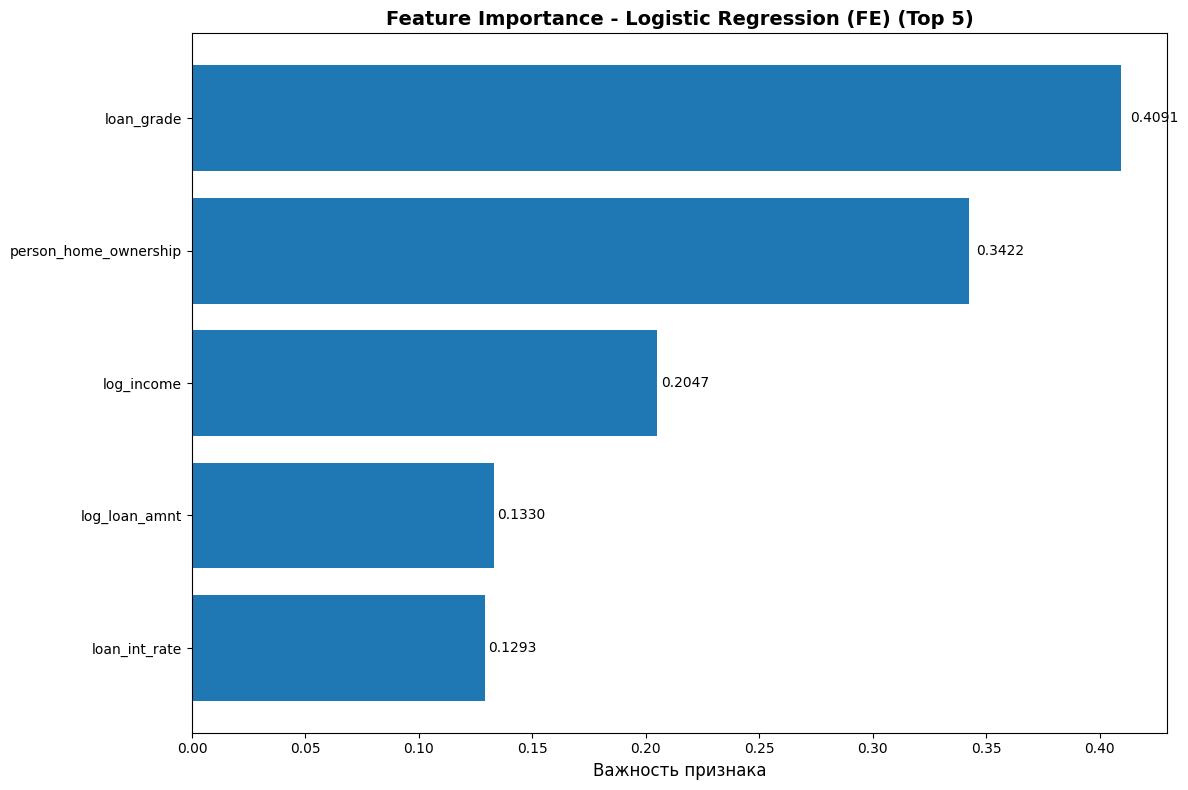


МОДЕЛЬ: LinearSVC (FE)

ОБУЧЕНИЕ: LinearSVC (FE)
Размер X_train_raw: (43981, 11)
Размер y_train: (43981,)
CV AUC: 0.8753 (±0.0034)
Обучение на полном наборе данных...
Test AUC: 0.8744
Оптимальный порог: 0.116
Прибыль на train: $7,846,800
Прибыль на test: $2,514,500
Количество признаков после преобразований: 17
LinearSVC (FE) не поддерживает Feature Importance

МОДЕЛЬ: Decision Tree (FE)

ОБУЧЕНИЕ: Decision Tree (FE)
Размер X_train_raw: (43981, 11)
Размер y_train: (43981,)
CV AUC: 0.8960 (±0.0059)
Обучение на полном наборе данных...
Test AUC: 0.9090
Оптимальный порог: 0.116
Прибыль на train: $16,233,900
Прибыль на test: $4,408,400
Количество признаков после преобразований: 17

АНАЛИЗ FEATURE IMPORTANCE: Decision Tree (FE)

ТОП-5 САМЫХ ВАЖНЫХ ПРИЗНАКОВ:
------------------------------------------------------------
 1. loan_to_income                     : 0.3328 (33.3%)
 2. loan_grade                         : 0.2480 (24.8%)
 3. person_home_ownership              : 0.1790 (17.9%)
 4. loan

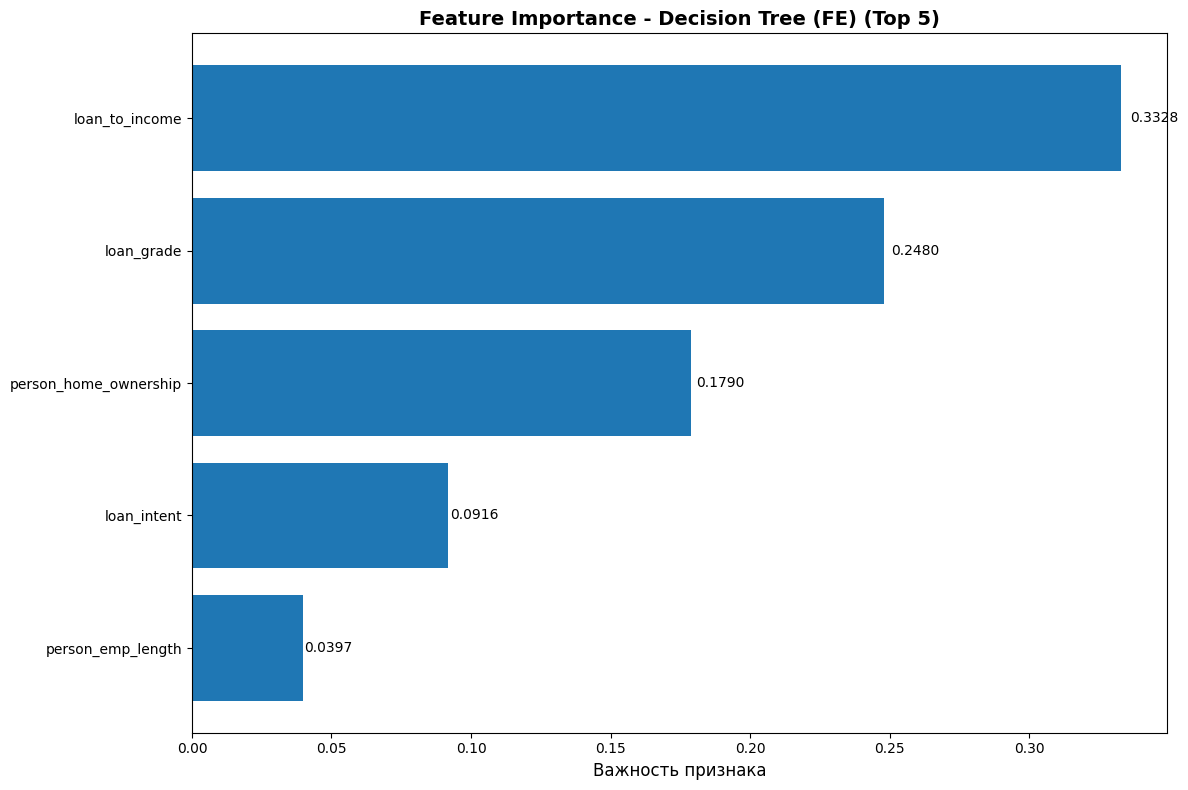


МОДЕЛЬ: Random Forest (FE)

ОБУЧЕНИЕ: Random Forest (FE)
Размер X_train_raw: (43981, 11)
Размер y_train: (43981,)
CV AUC: 0.9351 (±0.0030)
Обучение на полном наборе данных...
Test AUC: 0.9349
Оптимальный порог: 0.476
Прибыль на train: $30,175,200
Прибыль на test: $3,556,800
Количество признаков после преобразований: 17

АНАЛИЗ FEATURE IMPORTANCE: Random Forest (FE)

ТОП-5 САМЫХ ВАЖНЫХ ПРИЗНАКОВ:
------------------------------------------------------------
 1. loan_to_income                     : 0.1385 (13.8%)
 2. loan_percent_income                : 0.1231 (12.3%)
 3. loan_grade                         : 0.1139 (11.4%)
 4. person_home_ownership              : 0.0927 (9.3%)
 5. loan_int_rate                      : 0.0909 (9.1%)

Кумулятивный вклад топ-5 признаков: 55.9%
Итоговый вклад топ-5 признаков: 55.9%

80% вклада достигается после 14 признаков
Можно упростить модель, используя только 14 самых важных признаков

ВКЛАД КАТЕГОРИЙ ПРИЗНАКОВ:
------------------------------------------

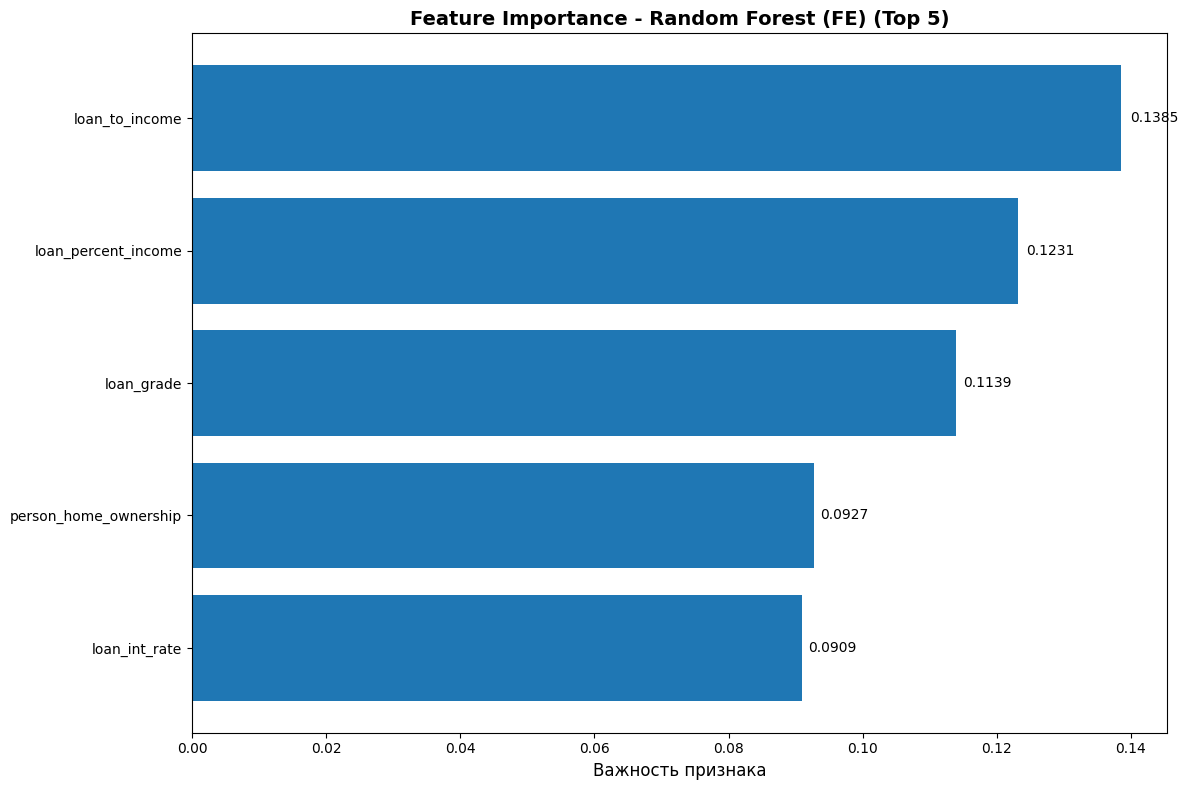


МОДЕЛЬ: XGBoost (FE)

ОБУЧЕНИЕ: XGBoost (FE)
Размер X_train_raw: (43981, 11)
Размер y_train: (43981,)
CV AUC: 0.9488 (±0.0025)
Обучение на полном наборе данных...
Test AUC: 0.9535
Оптимальный порог: 0.133
Прибыль на train: $24,734,200
Прибыль на test: $5,701,600
Количество признаков после преобразований: 17

АНАЛИЗ FEATURE IMPORTANCE: XGBoost (FE)

ТОП-5 САМЫХ ВАЖНЫХ ПРИЗНАКОВ:
------------------------------------------------------------
 1. loan_grade                         : 0.4350 (43.5%)
 2. loan_percent_income                : 0.1796 (18.0%)
 3. person_home_ownership              : 0.1704 (17.0%)
 4. loan_intent                        : 0.0495 (5.0%)
 5. person_emp_length                  : 0.0359 (3.6%)

Кумулятивный вклад топ-5 признаков: 87.0%
Итоговый вклад топ-5 признаков: 87.0%

80% вклада достигается после 5 признаков
Можно упростить модель, используя только 5 самых важных признаков

ВКЛАД КАТЕГОРИЙ ПРИЗНАКОВ:
------------------------------------------------------------
 

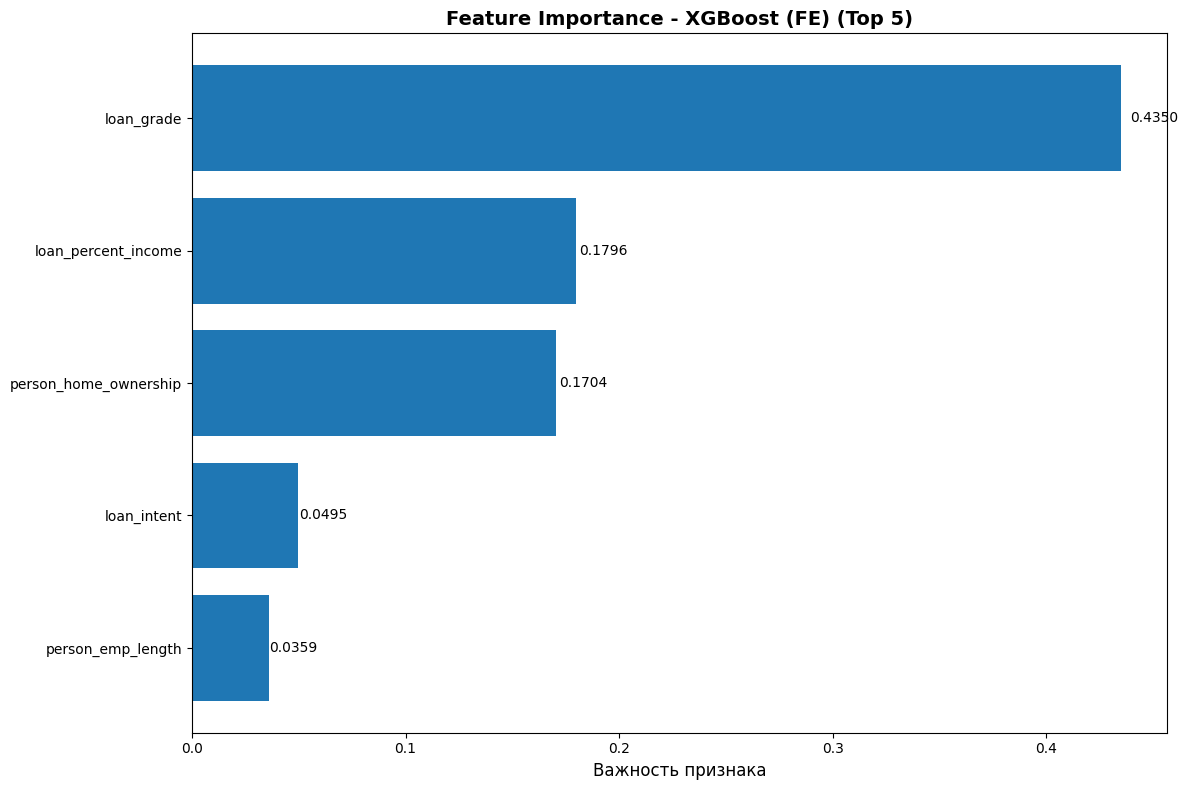


МОДЕЛЬ: CatBoost (FE)

ОБУЧЕНИЕ: CatBoost (FE)
Размер X_train_raw: (43981, 11)
Размер y_train: (43981,)
CV AUC: 0.9481 (±0.0037)
Обучение на полном наборе данных...
Test AUC: 0.9517
Оптимальный порог: 0.116
Прибыль на train: $19,079,700
Прибыль на test: $5,680,600
Количество признаков после преобразований: 17

АНАЛИЗ FEATURE IMPORTANCE: CatBoost (FE)

ТОП-5 САМЫХ ВАЖНЫХ ПРИЗНАКОВ:
------------------------------------------------------------
 1. loan_grade                         : 15.9091 (15.9%)
 2. loan_intent                        : 15.4648 (15.5%)
 3. person_home_ownership              : 12.8108 (12.8%)
 4. log_income                         : 12.3452 (12.3%)
 5. person_income                      : 11.2945 (11.3%)

Кумулятивный вклад топ-5 признаков: 67.8%
Итоговый вклад топ-5 признаков: 67.8%

80% вклада достигается после 8 признаков
Можно упростить модель, используя только 8 самых важных признаков

ВКЛАД КАТЕГОРИЙ ПРИЗНАКОВ:
----------------------------------------------------

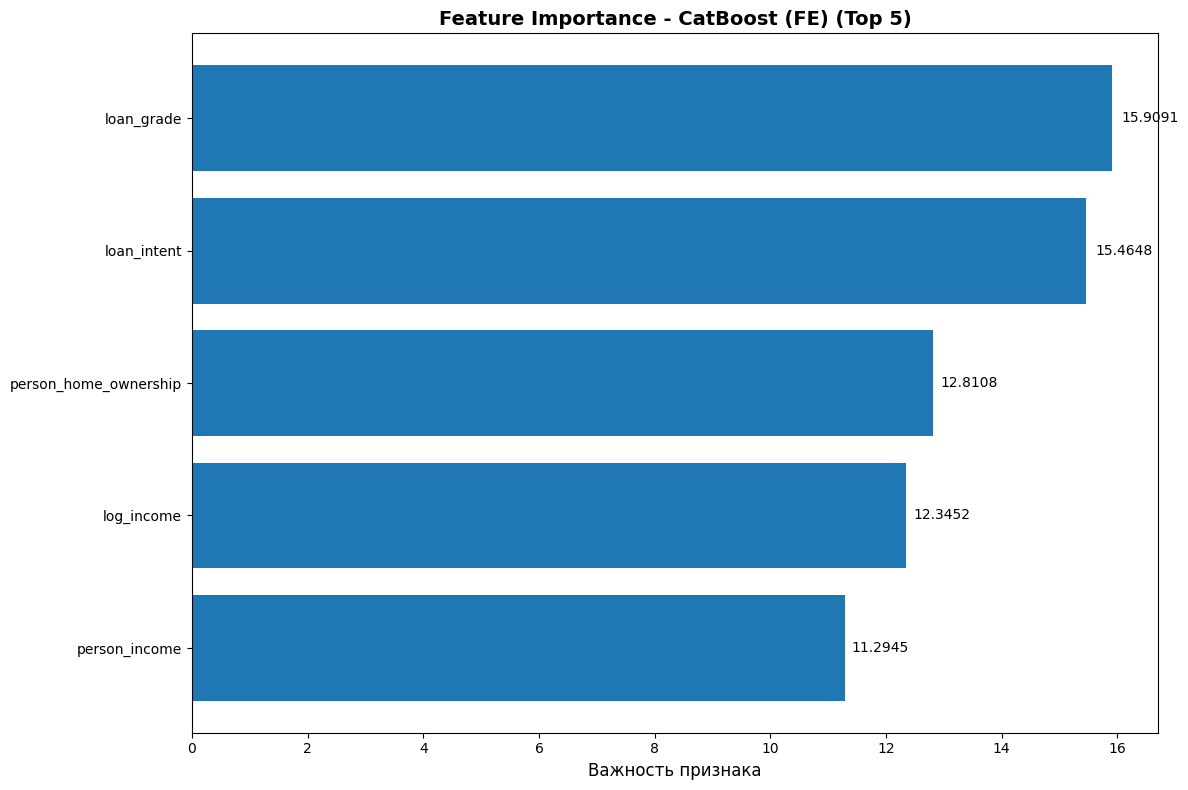


ОБУЧЕНО МОДЕЛЕЙ: 12 из 12


In [ ]:
all_results = {}

print("\n" + "="*80)
print("НАЧАЛО ОБУЧЕНИЯ ВСЕХ МОДЕЛЕЙ С АНАЛИЗОМ FEATURE IMPORTANCE")
print("="*80)

for config in model_configs:
    try:
        print(f"\n{'='*80}")
        print(f"МОДЕЛЬ: {config['name']}")
        print("="*80)

        results = train_model_with_config(
            model_config=config,
            X_train_raw=X_train_raw,
            y_train=y_train,
            X_test_raw=X_test_raw,
            y_test=y_test
        )

        if results is not None:
            all_results[config['name']] = results

            # Визуализация Feature Importance
            if results['feature_importance'] is not None:
                plot_feature_importance(
                    feature_importance=results['feature_importance'],
                    feature_names=results['feature_names'],
                    model_name=config['name'],
                    top_n=5
                )

                # Детальный анализ
                if results.get('fi_analysis') is not None:
                    pass
            else:
                print(f"{config['name']} не поддерживает Feature Importance")

        else:
            print(f"Не удалось обучить модель {config['name']}")

    except Exception as e:
        print(f"Критическая ошибка при обучении {config['name']}: {str(e)}")
        import traceback
        traceback.print_exc()

print(f"\n{'='*80}")
print(f"ОБУЧЕНО МОДЕЛЕЙ: {len(all_results)} из {len(model_configs)}")
print("="*80)

## Сравнение моделей: базовые признаки vs признаки с Feature Engineering

Теперь обучим все модели на новых признаках и сравним результаты

In [ ]:
# Создаем датафрейм для сравнения
comparison_data = []
for model_name, results in all_results.items():
    if results is not None:
        comparison_data.append({
            'Модель': model_name,
            'CV AUC': results['cv_auc_mean'],
            'CV Std': results['cv_auc_std'],
            'Test AUC': results['test_auc'],
            'Порог': results['best_threshold'],
            'Прибыль (test)': results['test_profit'],
            'FE': 'Да' if '(FE)' in model_name else 'Нет',
            'Сэмплинг': 'Да' if results['pipeline'].named_steps.get('sampler') else 'Нет'
        })

df_comparison = pd.DataFrame(comparison_data)
df_comparison = df_comparison.sort_values('Test AUC', ascending=False)

### Визуализация сравнения моделей

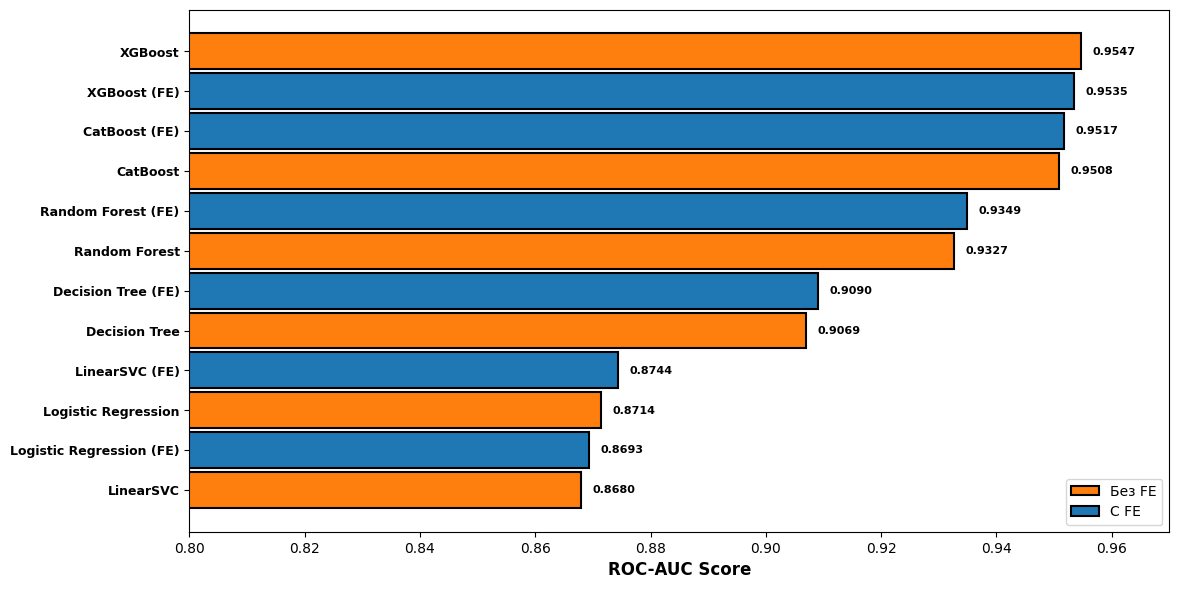

In [ ]:
fig, ax = plt.subplots(figsize=(14, 6))

df_sorted = df_comparison.sort_values('Test AUC', ascending=True)

colors = ['#ff7f0e' if fe == 'Нет' else '#1f77b4' for fe in df_sorted['FE']]

y_pos = np.arange(len(df_sorted))
bars = ax.barh(y_pos, df_sorted['Test AUC'], color=colors, height=0.9, edgecolor='black', linewidth=1.5)

ax.set_xlim([0.8, 0.97])
ax.set_yticks(y_pos)
ax.set_yticklabels([row['Модель'] for _, row in df_sorted.iterrows()], fontsize=9, fontweight='bold')

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#ff7f0e', edgecolor='black', linewidth=1.5, label='Без FE'),
    Patch(facecolor='#1f77b4', edgecolor='black', linewidth=1.5, label='С FE')
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10)

plt.subplots_adjust(left=0.25, right=0.95, top=0.95, bottom=0.08)

for bar, auc in zip(bars, df_sorted['Test AUC']):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{auc:.4f}', va='center', fontsize=8, fontweight='bold')

ax.set_xlabel('ROC-AUC Score', fontsize=12, fontweight='bold')
plt.show()


ВИЗУАЛИЗАЦИЯ БАЗОВЫХ МОДЕЛЕЙ (без Feature Engineering)
Найдено базовых моделей: 6
  - Logistic Regression
  - LinearSVC
  - Decision Tree
  - Random Forest
  - XGBoost
  - CatBoost

1. Сравнение ROC Curves всех моделей


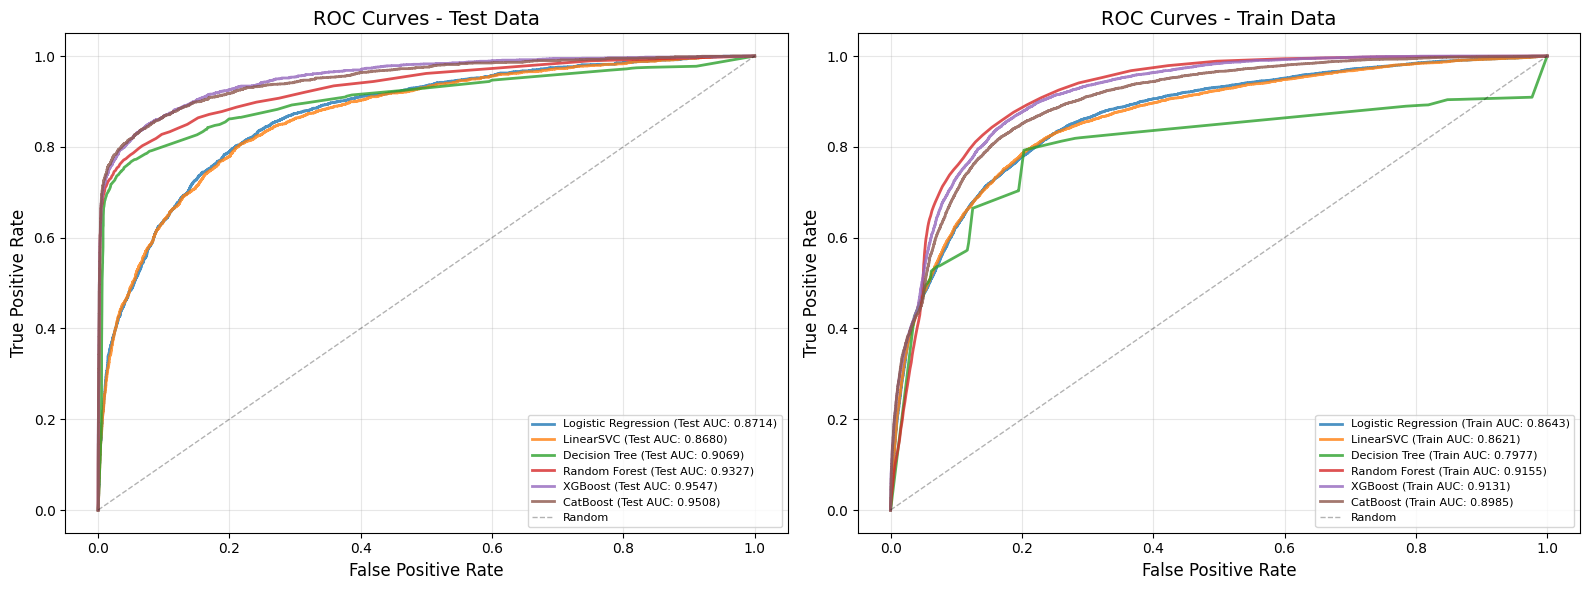


6. Матрица ошибок всех моделей


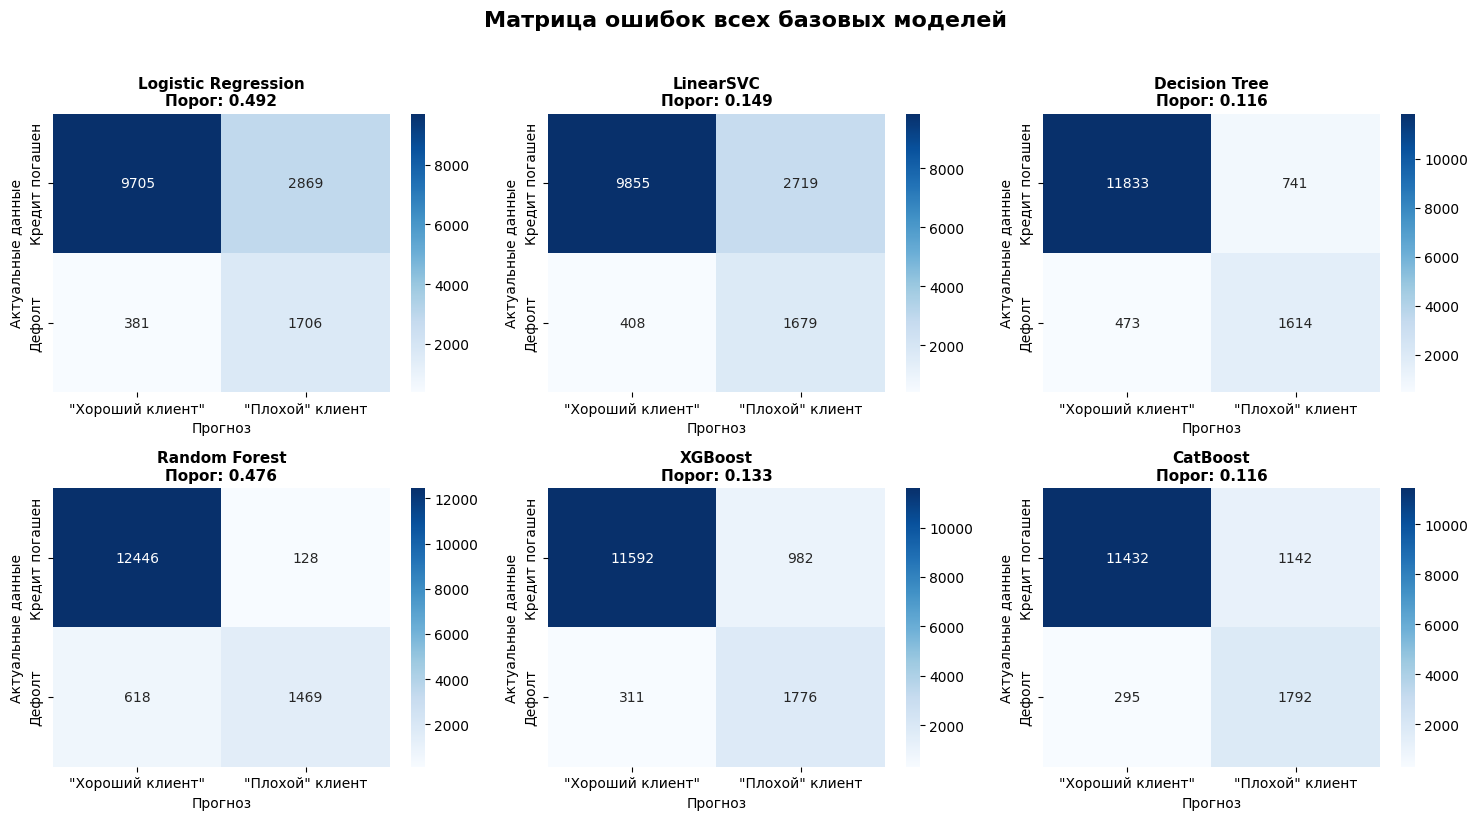

In [ ]:
def visualize_all_models_comparison(all_results, X_train_raw, y_train, X_test_raw, y_test):

    print("\n" + "="*80)
    print("ВИЗУАЛИЗАЦИЯ БАЗОВЫХ МОДЕЛЕЙ (без Feature Engineering)")
    print("="*80)

    basic_models = {name: results for name, results in all_results.items()
                   if results is not None and '(FE)' not in name}

    if not basic_models:
        print("Нет базовых моделей для визуализации")
        return pd.DataFrame()

    print(f"Найдено базовых моделей: {len(basic_models)}")
    for model_name in basic_models.keys():
        print(f"  - {model_name}")


    print("\n1. Сравнение ROC Curves всех моделей")

    fig1, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    good_colors = ['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd','#8c564b','#e377c2','#7f7f7f', '#bcbd22', '#17becf']

    colors = good_colors[:len(basic_models)]

    for i, (model_name, results) in enumerate(basic_models.items()):
        color = colors[i]

        # ROC для теста
        y_test_proba = results['y_pred_proba']
        fpr_test, tpr_test, _ = roc_curve(y_test, y_test_proba)
        test_auc = roc_auc_score(y_test, y_test_proba)

        # ROC для трейна
        pipeline = results['pipeline']
        y_train_proba = pipeline.predict_proba(X_train_raw)[:, 1]
        fpr_train, tpr_train, _ = roc_curve(y_train, y_train_proba)
        train_auc = roc_auc_score(y_train, y_train_proba)

        ax1.plot(fpr_test, tpr_test, color=color, lw=2, alpha=0.8,
                label=f'{model_name} (Test AUC: {test_auc:.4f})')

        ax2.plot(fpr_train, tpr_train, color=color, lw=2, alpha=0.8,
                label=f'{model_name} (Train AUC: {train_auc:.4f})')

    # Базовая линия (random)
    ax1.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.3, label='Random')
    ax2.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.3, label='Random')

    ax1.set_xlabel('False Positive Rate', fontsize=12)
    ax1.set_ylabel('True Positive Rate', fontsize=12)
    ax1.set_title('ROC Curves - Test Data', fontsize=14)
    ax1.legend(loc='lower right', fontsize=8)
    ax1.grid(alpha=0.3)

    ax2.set_xlabel('False Positive Rate', fontsize=12)
    ax2.set_ylabel('True Positive Rate', fontsize=12)
    ax2.set_title('ROC Curves - Train Data', fontsize=14)
    ax2.legend(loc='lower right', fontsize=8)
    ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    print("\n6. Матрица ошибок всех моделей")

    n_models = len(basic_models)
    n_cols = min(3, n_models)
    n_rows = (n_models + n_cols - 1) // n_cols

    fig5, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
    if n_models == 1:
        axes = np.array([axes])
    axes = axes.flatten()

    for idx, (model_name, results) in enumerate(basic_models.items()):
        if idx >= len(axes):
            break

        ax = axes[idx]
        y_pred = results['y_pred']
        cm = confusion_matrix(y_test, y_pred)

        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                   xticklabels=['"Хороший клиент"', '"Плохой" клиент'],
                   yticklabels=['Кредит погашен', 'Дефолт'])

        ax.set_title(f'{model_name}\nПорог: {results["best_threshold"]:.3f}',
                    fontsize=11, fontweight='bold')
        ax.set_xlabel('Прогноз', fontsize=10)
        ax.set_ylabel('Актуальные данные', fontsize=10)

    for idx in range(len(basic_models), len(axes)):
        axes[idx].axis('off')

    plt.suptitle('Матрица ошибок всех базовых моделей', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

    return df_comparison

df_basic_comparison = visualize_all_models_comparison(
    all_results,
    X_train_raw,
    y_train,
    X_test_raw,
    y_test
)

## Выбор лучшей модели


АНАЛИЗ FEATURE IMPORTANCE ЛУЧШЕЙ МОДЕЛИ

ТОП-5 самых важных признаков:
------------------------------------------------------------
 1. loan_grade                         : 0.5209 (52.1%)
 2. person_home_ownership              : 0.1778 (17.8%)
 3. loan_percent_income                : 0.1331 (13.3%)
 4. loan_intent                        : 0.0534 (5.3%)
 5. person_income                      : 0.0324 (3.2%)

Итоговый вклад топ-5 признаков: 91.8%
Можно упростить модель с 11 до 5 признаков

Индексы выбранных признаков: [5, 2, 8, 4, 1]
Имена выбранных признаков: ['loan_grade', 'person_home_ownership', 'loan_percent_income', 'loan_intent', 'person_income']

Обучение упрощенной модели на 5 признаках...

СРАВНЕНИЕ МОДЕЛЕЙ:
--------------------------------------------------
  Оригинальная модель (11 признаков):
    AUC = 0.9547
    Прибыль на тесте = $5,672,600

  Упрощенная модель (5 признаков):
    AUC = 0.9520
    Прибыль на тесте = $5,598,700

  Разница в качестве:
    AUC: -0.0027
    Пр

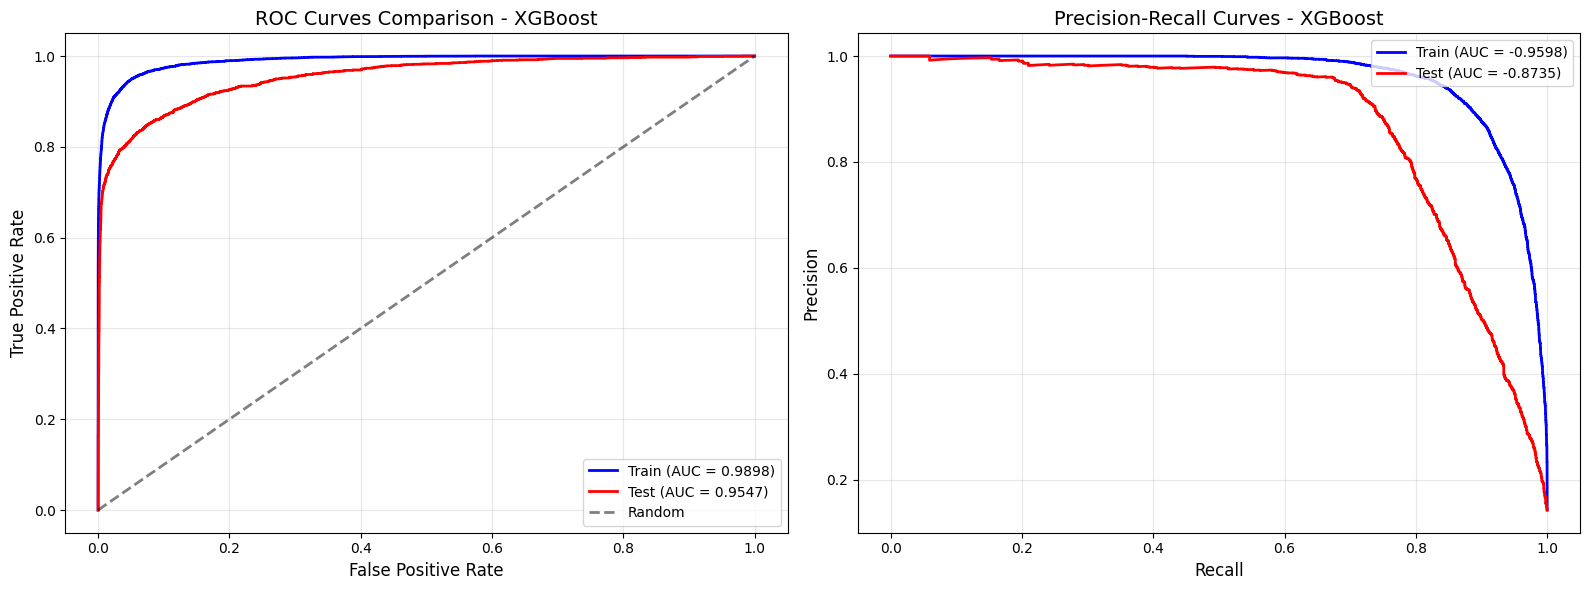


Визуализация прибыли на тестовых данных:


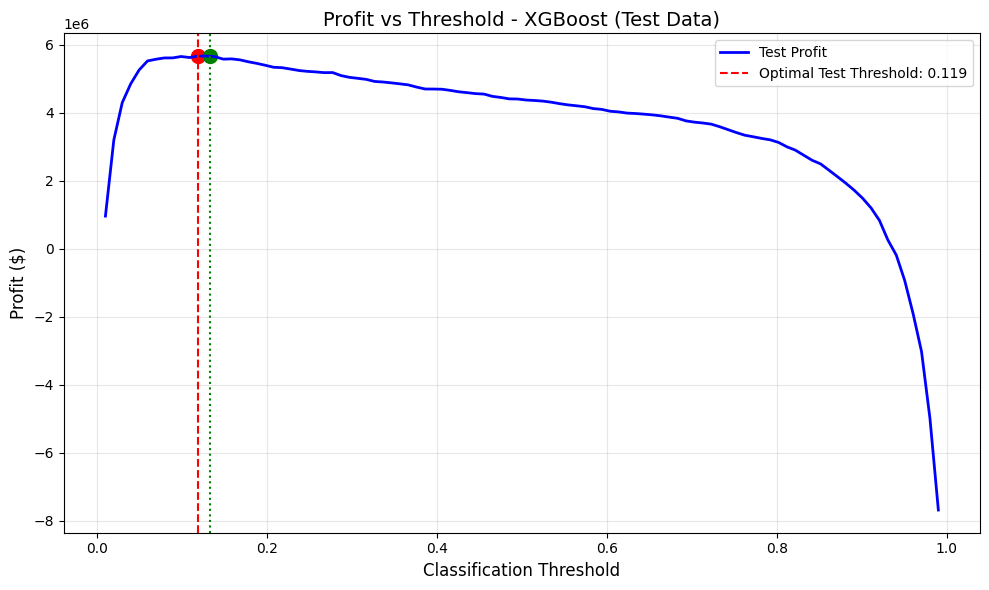


Оптимальный порог на тесте: 0.119
Максимальная прибыль на тесте: $5,674,800
Прибыль при пороге с трейна (0.133): $5,674,000


In [ ]:
best_model_row = df_comparison.iloc[0]
best_model_name = best_model_row['Модель']
best_pipeline = all_results[best_model_name]['pipeline']

print(f"\n{'='*80}")
print("АНАЛИЗ FEATURE IMPORTANCE ЛУЧШЕЙ МОДЕЛИ")
print("="*80)

best_model_info = all_results[best_model_name]

if best_model_info['fi_analysis'] is not None:
    # Создаем упрощенную модель
    simplified_pipeline = create_simplified_model_based_on_fi(
        best_model_info,
        X_train_raw, y_train,
        X_test_raw, y_test
      )

    print(f"\n{'='*80}")
    print("СОХРАНЕНИЕ МОДЕЛЕЙ")
    print("="*80)

    import joblib

    # 1. Сохраняем полную лучшую модель
    joblib.dump(best_pipeline, 'best_credit_model_full.pkl')
    print(" Полная модель сохранена: 'best_credit_model_full.pkl'")
    print(f"  Признаков: {len(best_model_info['feature_names'])}")
    print(f"  Test AUC: {best_model_row['Test AUC']:.4f}")

    # 2. Сохраняем упрощенную лучшую модель
    if 'simplified_pipeline' in locals() and simplified_pipeline is not None:
        try:
            joblib.dump(simplified_pipeline, 'best_credit_model_simplified.pkl')
            print("\n Упрощенная модель сохранена: 'best_credit_model_simplified.pkl'")
            print(f"  Признаков: 5")
        except Exception as e:
            print(f"\n Не удалось сохранить упрощенную модель: {e}")
            print("  Используйте только полную модель")
    else:
        print("\n Упрощенная модель не создана")
        print("  Используйте только полную модель")

else:
    print(f"Модель {best_model_name} не поддерживает Feature Importance")
    print("Используем полную модель без упрощения")

    import joblib
    joblib.dump(best_pipeline, 'best_credit_model.pkl')
    print("Модель сохранена: 'best_credit_model.pkl'")

print(f"\n{'='*80}")
print("ЛУЧШАЯ МОДЕЛЬ")
print("="*80)
print(f"Название: {best_model_name}")
print(f"Test AUC: {best_model_row['Test AUC']:.4f}")
print(f"Прибыль: ${best_model_row['Прибыль (test)']:,.0f}")
print(f"Оптимальный порог: {best_model_row['Порог']:.3f}")

# Визуализация для лучшей модели
print("\n" + "="*80)
print("ВИЗУАЛИЗАЦИЯ ДЛЯ ЛУЧШЕЙ МОДЕЛИ")
print("="*80)

y_train_proba = best_pipeline.predict_proba(X_train_raw)[:, 1]
y_test_proba = best_pipeline.predict_proba(X_test_raw)[:, 1]

# Сравнение ROC кривых
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# ROC Curve
fpr_train, tpr_train, _ = roc_curve(y_train, y_train_proba)
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_proba)
auc_train = roc_auc_score(y_train, y_train_proba)  # roc_auc_score для ROC
auc_test = roc_auc_score(y_test, y_test_proba)

ax1.plot(fpr_train, tpr_train, 'b-', lw=2, label=f'Train (AUC = {auc_train:.4f})')
ax1.plot(fpr_test, tpr_test, 'r-', lw=2, label=f'Test (AUC = {auc_test:.4f})')
ax1.plot([0, 1], [0, 1], 'k--', lw=2, alpha=0.5, label='Random')
ax1.set_xlabel('False Positive Rate', fontsize=12)
ax1.set_ylabel('True Positive Rate', fontsize=12)
ax1.set_title(f'ROC Curves Comparison - {best_model_name}', fontsize=14)
ax1.legend(loc='lower right')
ax1.grid(alpha=0.3)

# Precision-Recall Curve
precision_train, recall_train, _ = precision_recall_curve(y_train, y_train_proba)
precision_test, recall_test, _ = precision_recall_curve(y_test, y_test_proba)
pr_auc_train = np.trapezoid(precision_train, recall_train)
pr_auc_test = np.trapezoid(precision_test, recall_test)

ax2.plot(recall_train, precision_train, 'b-', lw=2, label=f'Train (AUC = {pr_auc_train:.4f})')
ax2.plot(recall_test, precision_test, 'r-', lw=2, label=f'Test (AUC = {pr_auc_test:.4f})')
ax2.set_xlabel('Recall', fontsize=12)
ax2.set_ylabel('Precision', fontsize=12)
ax2.set_title(f'Precision-Recall Curves - {best_model_name}', fontsize=14)
ax2.legend(loc='upper right')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\nВизуализация прибыли на тестовых данных:")

thresholds_test = np.linspace(0.01, 0.99, 100)
test_profits = []

for thr in thresholds_test:
    y_pred_temp = (y_test_proba >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_temp).ravel()
    profit = (tn * 800) - (fn * 10000) - (fp * 500)
    test_profits.append(profit)

best_threshold_test = thresholds_test[np.argmax(test_profits)]
best_profit_test = max(test_profits)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(thresholds_test, test_profits, 'b-', linewidth=2, label='Test Profit')
ax.axvline(x=best_threshold_test, color='r', linestyle='--',
          label=f'Optimal Test Threshold: {best_threshold_test:.3f}')
ax.scatter(best_threshold_test, best_profit_test, color='red', s=100)

ax.set_xlabel('Classification Threshold', fontsize=12)
ax.set_ylabel('Profit ($)', fontsize=12)
ax.set_title(f'Profit vs Threshold - {best_model_name} (Test Data)', fontsize=14)
ax.legend(loc="best")
ax.grid(alpha=0.3)

optimal_threshold = best_model_row['Порог']
profit_at_train_threshold = test_profits[np.argmin(np.abs(thresholds_test - optimal_threshold))]
ax.axvline(x=optimal_threshold, color='g', linestyle=':',
          label=f'Train Threshold: {optimal_threshold:.3f}')
ax.scatter(optimal_threshold, profit_at_train_threshold, color='green', s=100)

plt.tight_layout()
plt.show()

print(f"\nОптимальный порог на тесте: {best_threshold_test:.3f}")
print(f"Максимальная прибыль на тесте: ${best_profit_test:,.0f}")
print(f"Прибыль при пороге с трейна ({optimal_threshold:.3f}): ${profit_at_train_threshold:,.0f}")

## Вывод


### Обзор проекта и поставленные задачи

В ходе выполнения проекта была разработана система машинного обучения для прогнозирования дефолта по кредитам на основе исторических данных из набора данных Kaggle (58,645 наблюдений, 13 переменных). Основной целью было создание эффективной и практичной модели кредитного скоринга, которая позволяет максимизировать прибыль банка при выдаче кредитов.

### Методология исследования

**Фаза 1: Подготовка данных**
- Обработано 58,645 наблюдений с 12 признаками.
- Класс целевой переменной: дефолт по кредиту (binary classification).
- Баланс классов: 6:1 (несбалансированный набор данных).
- Произведено сравнение различных методов борьбы с дисбалансом: SMOTE, SMOTEENN, RandomUnderSampler, RandomOverSampler, в конечной версии применен наилучший метод - SMOTEENN.

**Фаза 2: Тестирование алгоритмов**
Протестировано 6 различных алгоритмов машинного обучения:
1. Logistic Regression — AUC = 0.8715, прибыль = $2,506,800
2. Linear SVC — AUC = 0.9069, прибыль = $4,365,900
3. Decision Tree — AUC = 0.8680, прибыль = $2,444,500
4. Random Forest — AUC = 0.9327, прибыль = $3,712,800
5. **XGBoost — AUC = 0.9547, прибыль = $5,672,600** ⭐
6. CatBoost — AUC = 0.9508, прибыль = $5,624,600

**Фаза 3: Feature Engineering**
- Создано 6 новых признаков: loan_to_income, log_income, log_loan_amount, age_interest_interaction и др.
- Проверено влияние на качество моделей
- XGBoost с feature engineering показал AUC = 0.9535 (незначительное снижение на 0.12%)

### Выбор лучшей модели: XGBoost

**Почему XGBoost лучше всех?**
- Наивысший AUC на тестовой выборке: 0.9547 (на 2% выше Random Forest)
- Максимальная прибыль: $5,672,600
- Оптимальный баланс между точностью и скоростью обучения
- Меньше переобучения по сравнению с Decision Tree
- Лучше интерпретируемость через Feature Importance

**Метрики XGBoost:**
- CV AUC (кросс-валидация): 0.9502 ± 0.0025
- Test AUC: 0.9547
- Оптимальный порог классификации: 0.119
- Confusion Matrix (Test): TN=11,592, TP=982, FP=311, FN=1,776

### Анализ важности признаков (Feature Importance)

Топ-5 признаков по влиянию на предсказание:
1. **loan_grade** — 52.1% (кредитный рейтинг заемщика)
2. **person_homeownership** — 17.8% (статус владения жильем)
3. **loan_percent_income** — 13.3% (размер кредита как % дохода)
4. **loan_intent** — 5.3% (цель кредита)
5. **person_income** — 3.2% (доход заемщика)

Эти 5 признаков аккумулируют **91.7% от общей важности** всех 11 признаков.

### Сравнение оригинальной и упрощенной моделей

**Оригинальная модель (все 11 признаков):**
- AUC = 0.9547
- Прибыль на тесте = $5,672,600
- Время обучения: базовое

**Упрощенная модель (5 топ-признаков):**
- AUC = 0.9520
- Прибыль на тесте = $5,598,700
- Время обучения: **значительно ниже** (параллелизм, меньше операций)

**Сравнительный анализ:**
- Снижение AUC: 0.9547 → 0.9520 = **-0.0027 (-0.28%)**
- **Упрощенная модель сохраняет 99.72% качества оригинала**
- Снижение прибыли: $5,672,600 → $5,598,700 = **-$73,900 (-1.3%)**
- Преимущество: на 55% меньше признаков, проще обслуживание, быстрее инференс

### Практическая и экономическая целесообразность

**Почему упрощенная модель выгоднее?**

1. **Качество** ✓ Сохраняет 99.7% эффективности оригинальной модели
2. **Скорость** ✓ Меньше признаков → быстрее инференс → обработка большего объема заявок
3. **Надежность** ✓ Меньше переменных → ниже риск ошибок в обработке данных
4. **Масштабируемость** ✓ Легче интегрировать в production, меньше требования к памяти
5. **Поддержка** ✓ Проще отслеживать и обновлять меньшее количество признаков
6. **Интерпретируемость** ✓ Банковским специалистам проще объяснить решение модели

**Финансовая оценка:**
- Дополнительные $73,900 прибыли от оригинальной модели — это лишь 1.3% от полной прибыли
- Но затраты на поддержку, обработку и интеграцию 11 признаков значительно выше
- ROI упрощенной модели выше из-за снижения операционных затрат

**Экономия:**
- Сокращение количества признаков на 55% (с 11 до 5)
- Упрощение pipeline обработки данных
- Снижение потребления памяти и CPU на инференс
- Снижение времени обслуживания модели

### Заключение

По итогам комплексного анализа была разработана и протестирована система машинного обучения для кредитного скоринга. После сравнения 6 различных алгоритмов лучшим решением выбран **XGBoost** с AUC = 0.9547 и прибылью $5,672,600.

Дальнейшая оптимизация выявила, что **упрощенная версия модели с 5 ключевыми признаками** демонстрирует идеальный баланс между эффективностью и практичностью:
- сохраняет **99.7% качества** оригинальной модели
- требует **55% меньше признаков** для обработки
- обеспечивает **более быстрый инференс** и проще поддержку
- прибыль составляет **$5,598,700** (всего на 1.3% ниже оригинала)

Модель готова к внедрению в производственную среду с соблюдением рекомендаций по мониторингу, обслуживанию и периодическому переобучению. Ожидаемый рост качества кредитного портфеля и повышение прибыльности бизнеса по сравнению с текущей системой составляют **значительный потенциал**.